<a id="eda"></a>

# <u>Exploratory data analysis - Hugo Fiévet</u>
# Exoplanet 2018 dataset 
-------

<a id="introduction"></a>

### 1. <u>Introduction</u>

Les [`exoplanètes`](#glossaire) sont généralement détectées indirectement. Dans la méthode des transits, la luminosité d’une étoile est mesurée au cours du temps. Lorsqu’un objet passe devant cette étoile, il provoque une légère diminution de sa luminosité, visible sous la forme d’un creux dans la courbe de lumière. La répétition de ce signal peut indiquer la présence d’une exoplanète, mais doit être vérifiée afin d’écarter les faux positifs.

L’objectif de ce travail est de développer un modèle de machine learning capable de classer des *Kepler Objects of Interest* ([`KOI`](#glossaire)) à partir de leurs caractéristiques observationnelles. La variable cible `koi_disposition` comporte trois classes : `CANDIDATE`, `CONFIRMED` et `FALSE POSITIVE`.

Ce notebook présente l’analyse exploratoire des données. Celle-ci permet d’obtenir une première compréhension du dataset, de ses variables, de leurs distributions, de leurs valeurs atypiques éventuelles et de leurs relations potentielles. Les résultats de cette analyse guideront ensuite les étapes de preprocessing, de sélection des variables et de modélisation.

---

<a id="transit-method"></a>

#### 1.1 <u>How the transit method works</u>

Avant d’analyser les données, il est utile de rappeler comment une partie des signaux étudiés par Kepler est obtenue. Le télescope ne photographie pas directement l’exoplanète : il mesure la luminosité de son étoile au cours du temps.

Lorsqu’une planète passe devant son étoile depuis le point de vue du télescope, elle masque une très petite partie de sa surface. La luminosité observée diminue alors légèrement. Cette diminution forme un creux dans la courbe de lumière. Si ce creux se répète à intervalles réguliers, il constitue un signal compatible avec le passage d’un objet en orbite et peut conduire à la détection d’un *Kepler Object of Interest* (KOI).

Le schéma suivant présente la géométrie simplifiée du transit et la traduction de ce phénomène dans une courbe de lumière.


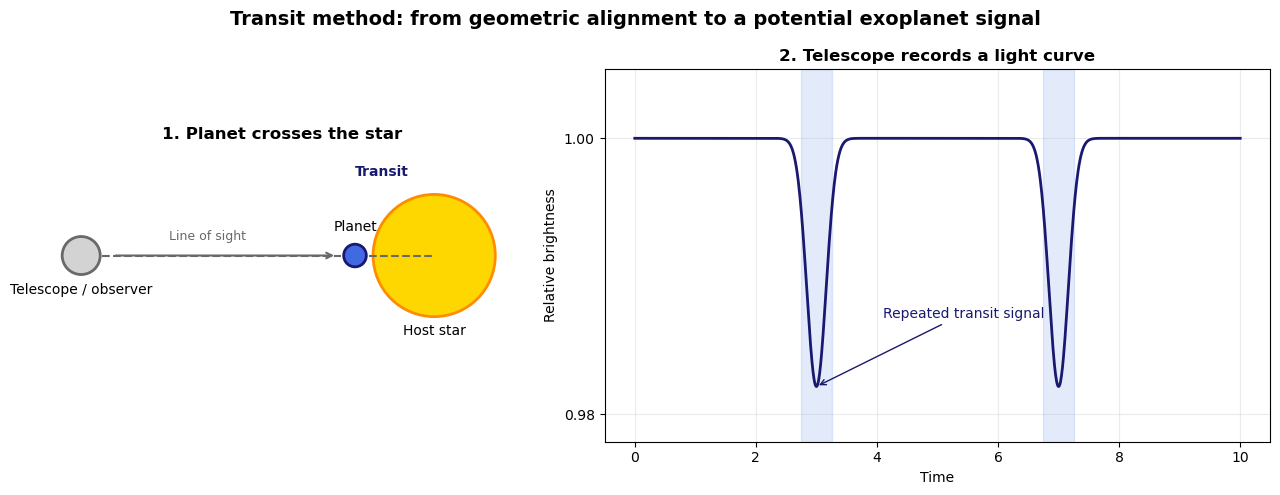

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


fig, (ax_geometry, ax_light_curve) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 5),
    gridspec_kw={"width_ratios": [1, 1.35]}
)


ax_geometry.set_aspect("equal")
ax_geometry.set_xlim(-1.7, 9.2)
ax_geometry.set_ylim(-2.4, 2.4)

observer = Circle((-0.7, 0), 0.42, facecolor="lightgrey", edgecolor="dimgray", linewidth=2)
star = Circle((7.1, 0), 1.35, facecolor="gold", edgecolor="darkorange", linewidth=2)
planet = Circle((5.35, 0), 0.25, facecolor="royalblue", edgecolor="midnightblue", linewidth=2)

ax_geometry.add_patch(observer)
ax_geometry.add_patch(star)
ax_geometry.add_patch(planet)

ax_geometry.plot([-0.25, 5.05], [0, 0], color="dimgray", linestyle="--", linewidth=1.5)
ax_geometry.plot([5.65, 7.05], [0, 0], color="dimgray", linestyle="--", linewidth=1.5)
ax_geometry.annotate(
    "",
    xy=(4.95, 0),
    xytext=(0.0, 0),
    arrowprops={"arrowstyle": "->", "color": "dimgray", "linewidth": 1.5}
)

ax_geometry.text(-0.7, -0.85, "Telescope / observer", ha="center", fontsize=10)
ax_geometry.text(7.1, -1.75, "Host star", ha="center", fontsize=10)
ax_geometry.text(5.35, 0.55, "Planet", ha="center", fontsize=10)
ax_geometry.text(2.1, 0.35, "Line of sight", ha="center", color="dimgray", fontsize=9)
ax_geometry.text(5.95, 1.75, "Transit", ha="center", color="midnightblue", fontsize=10, weight="bold")
ax_geometry.set_title("1. Planet crosses the star", fontsize=12, weight="bold")
ax_geometry.axis("off")

time = np.linspace(0, 10, 1200)
relative_brightness = np.ones_like(time)

for transit_center in (3.0, 7.0):
    relative_brightness -= 0.018 * np.exp(
        -0.5 * ((time - transit_center) / 0.16) ** 2
    )

ax_light_curve.plot(time, relative_brightness, color="midnightblue", linewidth=2)
ax_light_curve.axvspan(2.75, 3.25, color="cornflowerblue", alpha=0.18)
ax_light_curve.axvspan(6.75, 7.25, color="cornflowerblue", alpha=0.18)
ax_light_curve.annotate(
    "Repeated transit signal",
    xy=(3.0, 0.982),
    xytext=(4.1, 0.987),
    arrowprops={"arrowstyle": "->", "color": "midnightblue"},
    color="midnightblue",
    fontsize=10
)

ax_light_curve.set_title("2. Telescope records a light curve", fontsize=12, weight="bold")
ax_light_curve.set_xlabel("Time")
ax_light_curve.set_ylabel("Relative brightness")
ax_light_curve.set_ylim(0.978, 1.005)
ax_light_curve.set_yticks([0.98, 1.00])
ax_light_curve.grid(alpha=0.25)

fig.suptitle(
    "Transit method: from geometric alignment to a potential exoplanet signal",
    fontsize=14,
    weight="bold"
)
fig.tight_layout()
plt.show()


**Interprétation du schéma :** le télescope mesure la luminosité de l’étoile, et non la planète elle-même. Lorsque la planète passe devant l’étoile, la luminosité relative diminue légèrement, ce qui produit un creux dans la courbe de lumière. La répétition périodique de ce creux renforce l’hypothèse d’un objet en orbite.

Ce signal ne constitue toutefois pas, à lui seul, une preuve définitive d’une exoplanète. Une étoile binaire, une activité stellaire ou un problème instrumental peuvent produire un signal similaire. C’est pourquoi les objets détectés sont ensuite classés, notamment, comme `CANDIDATE`, `CONFIRMED` ou `FALSE POSITIVE`, ce qui correspond à la variable cible étudiée dans ce projet.


<a id="table-des-matieres"></a>
## Table des matières

- [1. Introduction](#introduction)
  - [1.1. How the transit method works](#transit-method)
- [2. Context and data source](#context-data-source)
- [3. Dataset overview](#dataset-overview)
- [4. Variable typology](#variable-typology)
- [5. Variable grouping](#variable-grouping)
- [6. Description of selected variables](#selected-variables)
  - [6.1. Research questions and analytical focus](#research-questions)
  - [6.2. Original reflection, biases and limitations](#original-reflection)
- [7. Data quality assessment](#data-quality)
  - [7.1. Global structure of the dataset](#dqa-structure)
  - [7.2. Type of data](#dqa-types)
  - [7.3. Missing values](#dqa-missing)
  - [7.4. Duplicates and repeated identifiers](#dqa-duplicates)
  - [7.5. Modalities of categorical variables](#dqa-categorical)
  - [7.6. Inconsistent or impossible values](#dqa-invalid)
- [8. Univariate analysis](#univariate)
  - [8.1. Target variable](#univariate-target)
  - [8.2. Categorical and binary variables](#univariate-categorical)
  - [8.3. Quantitative variables](#univariate-quantitative)
    - [8.3.1. Signal characteristics](#signal-characteristics)
    - [8.3.2. Object characteristics](#object-characteristics)
    - [8.3.3. Host-star characteristics](#host-star)
- [9. Bivariate analysis](#bivariate)
  - [9.1. Target variable versus another variable](#bivariate-one-variable)
  - [9.2. Two explanatory variables together](#bivariate-two-variables)
- [10. Astronomy glossary](#glossaire)
- [11. Sources](#sources)


<a id="context-data-source"></a>

### 2. <u>Context and data source</u>

<u>__Context__</u>

L’observatoire spatial Kepler est un satellite construit par la NASA et lancé en 2009. Le télescope a été conçu pour rechercher des exoplanètes dans des systèmes stellaires autres que le nôtre, notamment par la méthode des transits. Sa mission initiale a pris fin en 2013 à la suite de défaillances mécaniques, mais une mission prolongée, appelée « K2 », a ensuite été menée à partir de 2014. La mission K2 a pris fin en 2018 après l’épuisement du carburant du satellite.

En mai 2016, la NASA avait annoncé la confirmation de 1 284 nouvelles exoplanètes grâce aux données de Kepler. En octobre 2017, plus de 3 000 exoplanètes avaient été confirmées au total en utilisant l’ensemble des méthodes de détection, y compris les observations au sol.

---

<u>__Data source__</u>

Cet ensemble de données a été publié par la NASA. Il regroupe les objets d’intérêt observés par Kepler, ainsi que les paramètres utilisés pour caractériser les signaux détectés et leur attribuer une décision finale. Il contient environ 10 000 candidats exoplanétaires issus des observations de Kepler.


<a id="dataset-overview"></a>

### 3. <u>Dataset overview</u>

In [2]:
df_kepler = pd.read_csv("exoplanets_2018.csv")
df_kepler


,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,10090151,K07985.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,0,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9560,10128825,K07986.01,NaN,CANDIDATE,CANDIDATE,0.497,0,0,0,0,...,-220.0,4.444,0.056,-0.224,1.031,0.341,-0.114,286.50937,47.163219,14.757
9561,10147276,K07987.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.021,0,0,1,0,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385
9562,10155286,K07988.01,NaN,CANDIDATE,CANDIDATE,0.092,0,0,0,0,...,-128.0,2.992,0.030,-0.027,7.824,0.223,-1.896,296.76288,47.145142,10.998


Le chargement du fichier permet de vérifier que l'analyse porte bien sur la version locale de `exoplanets_2018.csv`. L'affichage initial sert à repérer les premières colonnes et à confirmer que le DataFrame a bien été créé avant l'étude détaillée de sa structure et de ses types.



<a id="variable-typology"></a>

### 4. <u>Variable typology</u> 

Avant de décrire individuellement les variables du dataset, il est utile de les regrouper en plusieurs familles. Cette étape permet de mieux comprendre le rôle de chaque colonne dans le dataset : certaines variables décrivent directement le candidat exoplanétaire, d’autres décrivent l’étoile hôte, tandis que certaines colonnes correspondent à des identifiants, des métadonnées techniques, des incertitudes de mesure ou des informations liées au processus de classification.

Cette typologie ne constitue pas une sélection de variables au sens du Machine Learning. Elle sert uniquement à organiser l’analyse exploratoire et à préparer la compréhension du dataset. Les choix définitifs concernant les variables utilisées pour la modélisation seront traités plus tard, dans les phases de prétraitement et de sélection de variables.

<u> Les variables du dataset peuvent être regroupées dans les familles suivantes : </u>

- Identifiants techniques de l’objet ou du candidat observé ;
- Variable cible ;
- Variables liées au statut ou au diagnostic de l’objet ;
- Flags binaires ;
- Mesures physiques du candidat exoplanétaire ;
- Mesures de l’étoile hôte ;
- Coordonnées célestes et magnitude apparente ;
- Incertitudes ou erreurs de mesure ;
- Métadonnées techniques;

---

<a id="variable-grouping"></a>

### 5. <u>Variable grouping</u>

Le tableau suivant présente quelques variables et leurs types associés afin d’en faciliter la lecture avant l’analyse statistique et graphique.

| Famille | Exemples de variables | Types statistiques présents | Rôle dans l’EDA |
|--------|------------------------|------------------------------|----------------|
| Identifiants techniques et désignation officielle | `kepid`, `kepoi_name`, `kepler_name` | Catégorielles nominales | Identifier les objets ou les candidats et repérer les répétitions |
| Variable cible | `koi_disposition` | Catégorielle nominale | Observer la répartition des classes |
| Variables liées au diagnostic | `koi_pdisposition`, `koi_score` | Catégorielle nominale, quantitative continue | Comprendre les informations proches du processus de classification |
| Flags binaires | `koi_fpflag_nt`, `koi_fpflag_ss`, `koi_fpflag_co`, `koi_fpflag_ec` | Catégorielles binaires | Identifier les indicateurs de faux positifs |
| Mesures du candidat ou du signal de transit | `koi_period`, `koi_duration`, `koi_depth`, `koi_prad` | Quantitatives continues | Étudier les propriétés du signal ou du candidat exoplanétaire |
| Mesures de l’étoile hôte | `koi_steff`, `koi_slogg`, `koi_srad` | Quantitatives continues | Étudier les propriétés physiques de l’étoile autour de laquelle le signal est détecté |
| Coordonnées et magnitude | `ra`, `dec`, `koi_kepmag` | Quantitatives continues | Situer les objets et analyser leur luminosité apparente |
| Incertitudes ou erreurs de mesure | `*_err1`, `*_err2` | Quantitatives continues | Évaluer l’incertitude associée aux mesures |
| Métadonnées techniques | `koi_tce_delivname` | Catégorielle nominale | Comprendre l’origine ou la version technique des données |


<a id="selected-variables"></a>

### 6. <u>Description of selected variables</u>

Après avoir regroupé les colonnes par familles, certaines variables seront expliquées plus en détail. Ce choix ne correspond pas encore à une sélection de variables pour la modélisation : il vise à faciliter l’interprétation de l’analyse exploratoire.

Les familles approfondies sont les suivantes :

- Identification de la cible Kepler : `kepid` ;
- Identification du candidat : `kepoi_name` ;
- Désignation officielle : `kepler_name` ;
- Mesures du candidat ou du signal de transit : `koi_period`, `koi_duration`, `koi_depth`, `koi_prad`, `koi_teq`, `koi_insol`, `koi_model_snr` ;
- Mesures de l’étoile hôte : `koi_steff`, `koi_slogg`, `koi_srad` ;
- Coordonnées et magnitude : `ra`, `dec`, `koi_kepmag` ;
- Variable cible : `koi_disposition`.

Ces variables sont centrales pour comprendre les distributions, les relations entre variables et les liens possibles avec la variable cible.

Avant de passer à leur description, il est utile de rappeler comment un candidat est détecté.

<u>**Method for detecting a KOI candidate:**</u>

La détection d’un candidat [`KOI`](#glossaire) s’effectue indirectement par la [`méthode des transits`](#glossaire). Kepler mesure la luminosité d’une étoile au cours du temps. Une diminution périodique de cette luminosité peut indiquer qu’un objet passe devant l’étoile et bloque une partie de sa lumière. Ce signal est alors enregistré comme un candidat KOI, mais il ne prouve pas encore la présence d’une exoplanète : des analyses complémentaires peuvent conduire à une confirmation ou à l’identification d’un faux positif.

| Variable | Famille | Type statistique | Signification | Unité | Point d’attention pour l’analyse |
|---------|---------|------------------|---------------|-------|----------------------------------|
| `kepid` | Identification de la cible Kepler | Catégorielle nominale | Identifiant de la cible Kepler provenant du [`KIC`](#glossaire), c’est-à-dire de l’étoile observée par le télescope | Aucune | Vérifier sa cohérence avec le nombre de répétitions |
| `kepoi_name` | Identification du candidat | Catégorielle nominale | Identifiant d’une entrée [`KOI`](#glossaire) correspondant à un signal de transit candidat associé à une cible Kepler | Aucune | Devrait être unique pour chaque candidat ; ce nom ne signifie pas que l’exoplanète est confirmée |
| `kepler_name` | Désignation officielle | Catégorielle nominale | Nom officiel attribué à certains objets confirmés ou validés comme exoplanètes | Aucune | Risque de lien direct avec `koi_disposition` |
| `koi_period` | Mesures du candidat ou du signal de transit | Quantitative continue | [`Période orbitale`](#glossaire) | **Jours** | Comparer sa distribution selon les classes de `koi_disposition` |
| `koi_duration` | Mesures du candidat ou du signal de transit | Quantitative continue | [`Durée du transit`](#glossaire) | **Heures** | Surveiller les durées atypiquement courtes ou longues |
| `koi_depth` | Mesures du candidat ou du signal de transit | Quantitative continue | [`Profondeur du transit`](#glossaire) | **Parties par million (ppm)** | Observer les transits très profonds et leur relation avec la cible |
| `koi_prad` | Mesures du candidat ou du signal de transit | Quantitative continue | [`Rayon planétaire`](#glossaire) | **Rayons terrestres ($R_\oplus$)** | Vérifier sa relation potentielle avec `koi_depth` |
| `koi_teq` | Mesures du candidat ou du signal de transit | Quantitative continue | [`Température d’équilibre estimée`](#glossaire) | **Kelvins (K)** | Vérifier les valeurs extrêmes et leur cohérence avec l’étoile hôte |
| `koi_insol` | Mesures du candidat ou du signal de transit | Quantitative continue | [`Flux d’insolation`](#glossaire) | **Flux terrestre** | Vérifier sa relation avec `koi_teq` et surveiller les valeurs élevées |
| `koi_model_snr` | Mesures du candidat ou du signal de transit | Quantitative continue | [`Qualité relative du signal de transit détecté`](#glossaire) | Aucune | Interpréter un faible SNR comme un indicateur d’une détection plus incertaine |
| `koi_impact` | Mesures du candidat ou du signal de transit | Quantitative continue | [`Paramètre d’impact du transit`](#glossaire) | **Rayons stellaires** | Examiner sa distribution, ses valeurs atypiques et sa relation avec la durée du transit et la cible |
| `koi_steff` | Mesures de l’étoile hôte | Quantitative continue | [`Température stellaire effective`](#glossaire) | **Kelvins (K)** | Observer sa relation avec `koi_teq` |
| `koi_slogg` | Mesures de l’étoile hôte | Quantitative continue | [`Logarithme de la gravité de surface de l’étoile hôte`](#glossaire) | **log10(cm/s²)** | La comparer avec le rayon stellaire `koi_srad` |
| `koi_srad` | Mesures de l’étoile hôte | Quantitative continue | [`Rayon stellaire estimé de l’étoile hôte`](#glossaire) | **Rayons solaires ($R_\odot$)** | Repérer les étoiles hôtes de taille atypique |
| `ra` | Coordonnées et magnitude | Quantitative continue circulaire | [`Ascension droite de la cible Kepler issue du KIC`](#glossaire) | **Degrés (°)** | Vérifier que les valeurs appartiennent à l’intervalle attendu |
| `dec` | Coordonnées et magnitude | Quantitative continue | [`Déclinaison de la cible Kepler issue du KIC`](#glossaire) | **Degrés (°)** | Vérifier que les valeurs appartiennent à l’intervalle théorique [-90°, +90°] |
| `koi_kepmag` | Coordonnées et magnitude | Quantitative continue | [`Magnitude apparente dans la bande Kepler`](#glossaire) | **Magnitude Kepler ($K_p$)** | Tenir compte de l’échelle inversée des magnitudes |
| `koi_disposition` | Variable cible | Catégorielle nominale | Statut attribué au [`KOI`](#glossaire) dans les archives d’exoplanètes | Aucune ; `CANDIDATE`, `CONFIRMED`, `FALSE POSITIVE` | Vérifier la répartition des classes et repérer un éventuel déséquilibre |

<u>**Explanation of the target modalities `koi_disposition`:**</u>

- **`CONFIRMED`** : le [`KOI`](#glossaire) est confirmé comme exoplanète ;
- **`CANDIDATE`** : le [`KOI`](#glossaire) est encore candidat et n’est pas définitivement confirmé ;
- **`FALSE POSITIVE`** : le signal est considéré comme un faux positif et ne correspond probablement pas à une exoplanète.


<a id="research-questions"></a>

#### 6.1. <u>Research questions and analytical focus</u>

 Les questions suivantes structurent l'EDA et relient les observations descriptives aux décisions qui seront prises lors du prétraitement et de la modélisation :

1. **La variable cible est-elle équilibrée ?** Si une classe est majoritaire, l'accuracy restera-t-elle suffisante pour évaluer correctement les trois classes ?
2. **Les variables proches du processus de décision, comme `koi_pdisposition` et les `koi_fpflag_*`, sont-elles fortement associées à `koi_disposition` ?** Leur pouvoir prédictif correspond-il à une information astrophysique ou risque-t-il de révéler indirectement la décision finale ?
3. **La qualité du signal, mesurée notamment par `koi_model_snr`, permet-elle de différencier les `CANDIDATE`, les `CONFIRMED` et les `FALSE POSITIVE` ?**
4. **Les caractéristiques du transit, comme `koi_period`, `koi_duration`, `koi_depth` et `koi_impact`, présentent-elles des distributions différentes selon la classe finale ?**
5. **Les variables physiques présentent-elles les relations attendues ?** Par exemple, le rayon planétaire est-il lié à la profondeur du transit et la température d'équilibre au flux d'insolation ?
6. **Certaines variables sont-elles redondantes ?** Une forte corrélation entre `koi_insol` et `koi_teq`, ou entre `koi_slogg` et `koi_srad`, pourrait influencer la sélection de variables.
7. **Les valeurs manquantes sont-elles distribuées au hasard ?** La présence ou l'absence d'un `kepler_name` semble-t-elle informative sur la classe finale ?
8. **Les répétitions de `kepid` limitent-elles la généralisation du modèle ?** Plusieurs candidats appartenant à la même étoile pourraient rendre une séparation aléatoire des lignes trop optimiste.

Ces questions ne supposent pas une relation causale. Elles servent à organiser l'observation, à formuler des hypothèses vérifiables et à préparer les choix du preprocessing.

<a id="original-reflection"></a>

#### 6.2. <u>Original reflection, biases and limitations</u>

Cette analyse ne porte pas sur un échantillon aléatoire de toutes les étoiles observées par Kepler. Le dataset contient déjà des **Kepler Objects of Interest (KOI)**, c'est-à-dire des signaux qui ont passé une première étape de détection. Le modèle étudié ensuite devra donc être interprété comme un modèle de classification de candidats déjà détectés, et non comme un modèle capable de repérer une exoplanète dans n'importe quelle étoile du ciel. Cette sélection initiale constitue un **biais de sélection**.

Plusieurs variables peuvent également refléter le processus de validation du catalogue plutôt qu'une propriété physique indépendante :

- `koi_pdisposition` est une décision préliminaire très proche de la décision finale `koi_disposition` ;
- les `koi_fpflag_*` signalent des indices utilisés pour identifier des faux positifs ;
- `kepler_name` est une désignation officielle attribuée seulement à une partie des objets, et sa présence est fortement associée au statut final.

Ces variables peuvent donc produire une **fuite d'information** si elles sont utilisées comme variables explicatives sans précaution. Une performance élevée obtenue grâce à ces colonnes ne signifierait pas nécessairement que le modèle apprend uniquement les propriétés du signal de transit. Elles devront être exclues ou faire l'objet d'une analyse séparée lors du preprocessing.

La répétition de `kepid` constitue une autre limite méthodologique. Plusieurs lignes peuvent correspondre à des candidats différents autour de la même étoile. Si des lignes d'une même étoile sont réparties à la fois dans l'entraînement et dans le test, le modèle pourrait bénéficier indirectement d'informations propres à cette étoile. Une séparation par groupe, basée sur `kepid`, serait plus stricte.

Enfin, une valeur atypique détectée par une règle statistique n'est pas automatiquement une erreur astrophysique. Les relations entre `koi_prad` et `koi_depth`, ou entre `koi_insol` et `koi_teq`, sont physiquement attendues et créent une redondance naturelle. L'EDA doit donc distinguer :

- une erreur de données, comme la valeur `465` dans un flag binaire ;
- une observation extrême mais potentiellement réelle ;
- une variable informative mais trop proche de la cible ;
- une variable physiquement redondante avec une autre.

Cette réflexion impose de justifier chaque suppression, correction ou transformation au lieu de traiter automatiquement toute valeur rare, extrême ou manquante comme une anomalie.



<a id="data-quality"></a>

### 7. <u>Data quality assessment</u>

Le but de cette partie est d’évaluer la qualité du jeu de données avant de poursuivre son analyse. Chaque sous-section étudie un aspect particulier :

- la structure globale du dataset ;
- les types de données présents ;
- les valeurs manquantes ;
- les doublons et les répétitions d’identifiants ;
- les modalités des variables catégorielles ;
- les valeurs incohérentes.


<a id="dqa-structure"></a>

#### 7.1 <u>Global structure of the dataset</u> 
     

Cette sous-section fournit un premier aperçu de la structure globale du dataset. La méthode <code>.info()</code> permet d’observer ses dimensions, les types informatiques des variables et le nombre de valeurs non nulles pour chaque colonne. Ces éléments seront approfondis dans les sous-sections suivantes.


In [3]:
df_kepler.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 49 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   kepid              9564 non-null   int64  
 1   kepoi_name         9564 non-null   object 
 2   kepler_name        2359 non-null   object 
 3   koi_disposition    9564 non-null   object 
 4   koi_pdisposition   9564 non-null   object 
 5   koi_score          8054 non-null   float64
 6   koi_fpflag_nt      9564 non-null   int64  
 7   koi_fpflag_ss      9564 non-null   int64  
 8   koi_fpflag_co      9564 non-null   int64  
 9   koi_fpflag_ec      9564 non-null   int64  
 10  koi_period         9564 non-null   float64
 11  koi_period_err1    9110 non-null   float64
 12  koi_period_err2    9110 non-null   float64
 13  koi_time0bk        9564 non-null   float64
 14  koi_time0bk_err1   9110 non-null   float64
 15  koi_time0bk_err2   9110 non-null   float64
 16  koi_impact         9201 

Alors que la source annonce initialement 10 000 observations, le dataset chargé contient 9 564 lignes et 49 colonnes. Cette différence de 436 observations devra être vérifiée afin de déterminer si elle provient de la version du fichier utilisée ou d’une étape de sélection effectuée en amont. On observe également que 36 colonnes contiennent au moins une valeur manquante, dont koi_teq_err1 et koi_teq_err2, qui sont entièrement vides. Une analyse plus précise des valeurs manquantes sera réalisée dans la sous-section dédiée.

---

<a id="dqa-types"></a>

#### 7.2 <u>Type of data</u>
    

Cette sous-section vise à vérifier si le type informatique de chaque colonne correspond bien à sa nature statistique. Pour cela, nous examinerons le type Pandas et le nombre de valeurs distinctes de chaque variable. Cette vérification permettra de repérer d’éventuelles incohérences de typage et de mieux distinguer les variables quantitatives, catégorielles, binaires et identificatrices.

In [4]:
def type_and_distinct_values(data_frame):
    """Retourne le type Pandas et le nombre de valeurs distinctes de chaque colonne.

    Parameters
    ----------
    data_frame : pandas.DataFrame
        DataFrame dont les colonnes doivent être décrites.

    Returns
    -------
    pandas.DataFrame
        Tableau contenant le nom de chaque colonne, son type informatique
        et son nombre de valeurs distinctes. Les valeurs manquantes ne sont
        pas comptées comme des valeurs distinctes.
    """
    col_types = data_frame.dtypes
    nb_distincts_vals_cols = data_frame.nunique()
    stats_df = pd.DataFrame(
        zip(data_frame.columns, col_types, nb_distincts_vals_cols)
    )
    stats_df.columns = [
        "Column name",
        "Type of column",
        "Total unique values"
    ]
    return stats_df


type_and_distinct_values(df_kepler)


,Column name,Type of column,Total unique values
0,kepid,int64,8214
1,kepoi_name,object,9564
2,kepler_name,object,2359
3,koi_disposition,object,3
4,koi_pdisposition,object,2
5,koi_score,float64,650
6,koi_fpflag_nt,int64,3
7,koi_fpflag_ss,int64,2
8,koi_fpflag_co,int64,2
9,koi_fpflag_ec,int64,2


1. La colonne `kepid` possède 8 214 valeurs distinctes pour 9 564 lignes, ce qui signale la présence d’identifiants répétés. Ce point sera étudié dans la section [`Doublons et répétitions`](#dqa-duplicates).

2. La colonne `koi_fpflag_nt` possède **3 valeurs distinctes**, contrairement aux autres indicateurs `koi_fpflag_ss`, `koi_fpflag_co` et `koi_fpflag_ec`, qui n’en possèdent que **2**. Les modalités de ces variables seront examinées dans la section [`Modalités des variables catégorielles`](#dqa-categorical).

3. La variable `koi_tce_plnt_num` est stockée au format `float64`, mais possède seulement **8 valeurs distinctes**. Son type informatique **ne suffit donc pas** à déterminer sa nature statistique.

4. Les variables `koi_teq_err1` et `koi_teq_err2` possèdent **0 valeur distincte**, car elles sont **entièrement vides**.

5. Certaines variables de type `object` possèdent peu de modalités et peuvent être catégorielles, tandis que d’autres, comme `kepoi_name`, jouent plutôt le rôle d’identifiants.

Ces observations ne permettent pas encore de conclure à une erreur de typage. Chaque point sera approfondi dans la section qui lui est consacrée.


<a id="dqa-missing"></a>

#### 7.3 <u>Missing values</u>
    

**<u>Objective:</u>**

Cette sous-section vise à évaluer le pourcentage de valeurs manquantes dans chaque colonne afin de comprendre leur impact sur la qualité du jeu de données.

**<u>Measurement method:</u>**

Le nombre brut permet de quantifier directement les valeurs manquantes. Le pourcentage fournit la même information sous une forme relative au nombre total de lignes. Comme toutes les colonnes contiennent 9 564 lignes dans ce dataset, ces deux mesures sont équivalentes pour comparer les variables.

**<u>Guidance for future preprocessing:</u>**

Cette partie permettra d’orienter le traitement des colonnes de manière appropriée lors de l’étape de **preprocessing**.


,Column name,Missing values,Total observations,Missing values percentage
30,koi_teq_err2,9564,9564,100.000000
29,koi_teq_err1,9564,9564,100.000000
2,kepler_name,7205,9564,75.334588
5,koi_score,1510,9564,15.788373
39,koi_steff_err2,483,9564,5.050188
45,koi_srad_err2,468,9564,4.893350
44,koi_srad_err1,468,9564,4.893350
42,koi_slogg_err2,468,9564,4.893350
41,koi_slogg_err1,468,9564,4.893350
38,koi_steff_err1,468,9564,4.893350


<Axes: >

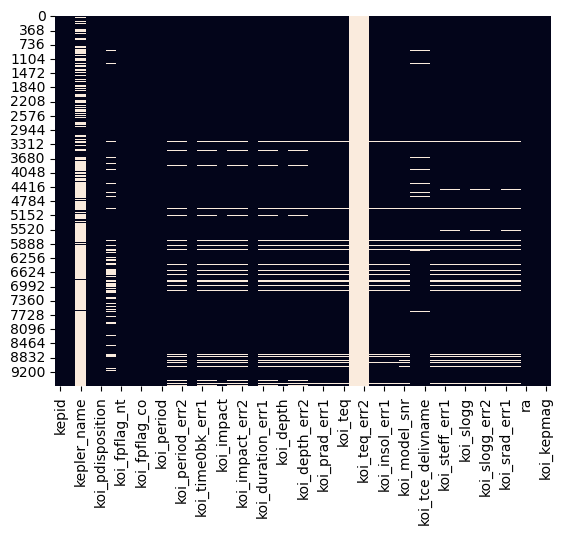

In [5]:
import pandas as pd


def missing_val_stats(df):
    """Calcule les statistiques de valeurs manquantes pour chaque colonne.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame à analyser.

    Returns
    -------
    pandas.DataFrame
        Tableau contenant, pour chaque colonne, le nombre de valeurs
        manquantes, le nombre total d'observations et le pourcentage de
        valeurs manquantes. Le résultat est trié par pourcentage décroissant.

    Notes
    -----
    Le pourcentage est calculé par rapport au nombre total de lignes du
    DataFrame. Cette fonction décrit les valeurs manquantes, mais ne décide
    pas de la manière dont elles seront traitées.
    """
    col_names = []
    total_obs = []
    total_na = []
    na_percentages = []

    total_val = len(df)

    for col in df.columns:
        col_names.append(col)

        na_count = df[col].isna().sum()

        total_obs.append(total_val)
        total_na.append(na_count)
        na_percentages.append((na_count / total_val) * 100)

    df_stats_na_val = pd.DataFrame({
        "Column name": col_names,
        "Missing values": total_na,
        "Total observations": total_obs,
        "Missing values percentage": na_percentages
    })

    return df_stats_na_val.sort_values(
        by="Missing values percentage",
        ascending=False
    )


missing_rate = df_kepler.isna().sum() / df_kepler.shape[0] * 100
missing_val_stats(df_kepler)

sns.heatmap(df_kepler.isna(), cbar=False)


Le tableau met en évidence quatre colonnes particulièrement touchées par les valeurs manquantes : `koi_teq_err1` et `koi_teq_err2`, qui sont **entièrement vides**, `kepler_name`, dont **75,33 % des valeurs sont manquantes**, et `koi_score`, qui présente **15,79 % de valeurs manquantes**. À l’inverse, **13 colonnes sont complètes** et **32 colonnes** possèdent au **maximum 5 % de valeurs manquantes**.

Pour `koi_teq_err1` et `koi_teq_err2`, on peut uniquement constater que les incertitudes correspondantes ne sont pas renseignées dans cette version du dataset. Cela ne permet pas de conclure qu’elles n’existent pas ou qu’elles ne sont pas applicables.

D’après la description de `kepler_name`, cette variable correspond à une désignation attribuée aux objets confirmés ou validés comme planètes. Ses valeurs manquantes pourraient donc s’expliquer par l’absence de désignation officielle. Cette variable devra être examinée avec prudence, car elle pourrait être fortement liée à `koi_disposition` et introduire une fuite de cible dans le modèle.

Ces résultats permettent d’identifier les variables nécessitant une attention particulière. Ils ne suffisent toutefois pas encore à décider automatiquement de leur suppression ou de leur imputation ; ces décisions seront prises lors du preprocessing, après l’étude de leur signification et de leur relation avec la variable cible.

---

<a id="dqa-duplicates"></a>

#### 7.4 <u>Duplicates and repeated identifiers</u>
    

<u>**Objective:**</u>

L’objectif est de repérer les doublons de lignes, c’est-à-dire au moins deux lignes identiques sur toutes les colonnes. Nous examinons également les répétitions d’identifiants. Cela permet de détecter d’éventuelles anomalies et de déterminer si ces répétitions sont intentionnelles ou accidentelles.

<u>**Measurement method:**</u>

La cellule suivante mesure :

- le nombre de lignes entièrement dupliquées ;
- le nombre d’occurrences supplémentaires pour plusieurs colonnes identifiantes.


In [6]:
def duplication_by_id_variables(df):
    """Compte les occurrences supplémentaires de plusieurs identifiants.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame contenant les colonnes ``kepid``, ``kepoi_name``, ``ra``
        et ``dec``.

    Returns
    -------
    pandas.DataFrame
        Tableau indiquant, pour chaque colonne contrôlée, le nombre
        d'occurrences supplémentaires après la première apparition d'une
        même valeur.

    Notes
    -----
    La méthode ``duplicated`` ne compte pas la première apparition d'une
    valeur comme une répétition. Cette fonction ne recherche pas les lignes
    entièrement dupliquées.
    """
    cols_names = ["kepid", "kepoi_name", "ra", "dec"]

    nb_duplications = [
        df.duplicated(subset=col).sum()
        for col in cols_names
    ]

    df_col_and_duplications = pd.DataFrame(
        zip(cols_names, nb_duplications)
    )
    df_col_and_duplications.columns = [
        "Column name",
        "Number of repetitions"
    ]

    return df_col_and_duplications


nb_duplicated_rows = df_kepler.duplicated().sum()
df_duplications_by_id_col = duplication_by_id_variables(df_kepler)

nb_duplicated_rows
df_duplications_by_id_col


np.int64(0)

,Column name,Number of repetitions
0,kepid,1350
1,kepoi_name,0
2,ra,1433
3,dec,1369


Les résultats montrent qu’**aucune ligne n’est entièrement dupliquée**. La variable `kepoi_name` ne présente également **aucune répétition**, ce qui indique que chaque candidat possède **un identifiant distinct** dans ce dataset.

En revanche, **1 350 lignes** correspondent à des **occurrences supplémentaires** d’un même `kepid`. Cette répétition ne constitue pas nécessairement une anomalie : plusieurs candidats ou signaux peuvent être associés à une même cible Kepler. Il s’agit donc d’une répétition d’identifiant de cible et non d’un doublon de ligne.

Les variables `ra` et `dec` présentent également des répétitions. Toutefois, leurs nombres ne doivent pas être interprétés séparément : une même ascension droite ou une même déclinaison peut appartenir à plusieurs positions différentes. Pour vérifier si plusieurs lignes correspondent exactement à la même position céleste, il faudrait analyser la combinaison de `ra` et `dec`.


<a id="dqa-categorical"></a>

#### 7.5 <u>Modalities of categorical variables</u>

<u>**Objective:**</u>

Cette sous-section permet de répondre aux objectifs suivants :

- identifier les modalités réellement présentes dans chaque variable catégorielle ;
- les comparer aux modalités attendues d’après la documentation ou la définition de la variable ;
- examiner leur répartition afin de repérer les catégories très rares, dominantes, inattendues ou mal écrites.

<u>**Measurement:**</u>

Pour chaque variable catégorielle sélectionnée, nous calculons :

- les modalités présentes ;
- le nombre d’occurrences de chaque modalité ;
- la proportion de chaque modalité dans le dataset.


Les variables catégorielles retenues sont `koi_disposition`, qui correspond au statut final du KOI, `koi_pdisposition`, qui représente sa classification préliminaire, `koi_tce_delivname`, qui indique la livraison TCE associée, ainsi que les indicateurs binaires `koi_fpflag_*`.


<u>**List of variables to analyse:**</u>

| Variable | Modalités attendues |
|--------|---------------------|
| `koi_fpflag_*` (nt, ss, co, ec) | `0, 1` |
| `koi_disposition` | `CANDIDATE, CONFIRMED, FALSE POSITIVE` |
| `koi_pdisposition` | `CANDIDATE, FALSE POSITIVE` |
| `koi_tce_delivname` | `q1_q16_tce, q1_q17_dr24_tce, q1_q17_dr25_tce` |


In [7]:
def modalities_stats(df, cols_name):
    """Calcule les effectifs et les proportions des modalités sélectionnées.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame contenant les variables catégorielles à analyser.
    cols_name : list[str]
        Noms des colonnes catégorielles à étudier.

    Returns
    -------
    pandas.DataFrame
        Tableau contenant, pour chaque colonne et chaque modalité, le nombre
        d'occurrences et le pourcentage correspondant. Les valeurs manquantes
        sont considérées comme une modalité grâce à ``dropna=False``.
    """
    df_modalities = []

    for column in cols_name:
        counts = df[column].value_counts(dropna=False)
        total_counts = counts.sum()

        for modal_name, count in counts.items():
            df_modalities.append(
                (
                    column,
                    modal_name,
                    count,
                    ((count / total_counts) * 100).round(2)
                )
            )

    df_modalities = pd.DataFrame(df_modalities)
    df_modalities.columns = [
        "Column name",
        "Modality name",
        "Count of each modality",
        "Percentage of each modality"
    ]

    return df_modalities


categorical_cols_names = [
    "koi_disposition",
    "koi_pdisposition",
    "koi_tce_delivname",
    "koi_fpflag_nt",
    "koi_fpflag_ss",
    "koi_fpflag_co",
    "koi_fpflag_ec"
]
df_mod_stats = modalities_stats(df_kepler, categorical_cols_names)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

df_mod_stats


,Column name,Modality name,Count of each modality,Percentage of each modality
0,koi_disposition,FALSE POSITIVE,4840,50.61
1,koi_disposition,CANDIDATE,2367,24.75
2,koi_disposition,CONFIRMED,2357,24.64
3,koi_pdisposition,FALSE POSITIVE,4847,50.68
4,koi_pdisposition,CANDIDATE,4717,49.32
5,koi_tce_delivname,q1_q17_dr25_tce,8054,84.21
6,koi_tce_delivname,q1_q16_tce,796,8.32
7,koi_tce_delivname,q1_q17_dr24_tce,368,3.85
8,koi_tce_delivname,NaN,346,3.62
9,koi_fpflag_nt,0,8033,83.99


À l’exception de la valeur **465** observée dans `koi_fpflag_nt`, les modalités non manquantes correspondent aux valeurs attendues. Cette variable étant un indicateur binaire, la valeur **465**, présente une seule fois, est inattendue et doit être vérifiée avant toute correction.

Concernant la répartition des modalités, on peut observer plusieurs tendances :

- `koi_disposition` : la modalité `FALSE POSITIVE` est majoritaire avec environ **51 %** des observations, tandis que `CANDIDATE` et `CONFIRMED` représentent chacune environ **24 %** ;
- `koi_pdisposition` : la classification préliminaire est presque équilibrée : **50,68 %** des KOI sont classés `FALSE POSITIVE` et **49,32 %** `CANDIDATE` ;
- `koi_tce_delivname` :
  - `q1_q17_dr25_tce` est majoritaire avec **84,21 %**. Il s’agit de la livraison DR25 couvrant les trimestres Q1 à Q17, traitée avec le [`Robovetter`](#glossaire) ;
  - `q1_q16_tce` représente **8,32 %** des observations et correspond à une livraison couvrant Q1 à Q16 ;
  - `q1_q17_dr24_tce` représente **3,85 %** des observations et correspond à une livraison antérieure couvrant Q1 à Q17 ;
  - enfin, **3,62 %** des valeurs sont manquantes.


<a id="dqa-invalid"></a>

#### 7.6 <u>Inconsistent or impossible values</u> 
    

Cette partie est consacrée à la vérification des résultats obtenus dans les sous-sections précédentes, ainsi qu’à la détection de valeurs incohérentes ou impossibles. L’analyse porte notamment sur les variables représentant des mesures physiques, des coordonnées astronomiques et des indicateurs binaires.


Afin de cibler cette vérification, les variables ont été regroupées selon leur nature : coordonnées astronomiques, indicateurs binaires, scores, nombres entiers et mesures physiques. Pour chacune d’elles, le domaine de valeurs attendu sera comparé aux valeurs réellement présentes dans le dataset. Les identifiants et les noms ne sont pas concernés par cette vérification, car ils ne représentent pas des mesures physiques.

<u>**Variables to check:**</u>

| Groupe | Variables | Vérification |
|--------|-----------|--------------|
| Coordonnées | `ra`, `dec` | `0 ≤ ra < 360` ; `−90 ≤ dec ≤ 90` |
| Score | `koi_score` | Valeur comprise entre 0 et 1 |
| Flags binaires | `koi_fpflag_*` | Uniquement 0 ou 1 |
| Numéro de planète/TCE | `koi_tce_plnt_num` | Entier strictement positif |
| Mesures du candidat | `koi_period`, `koi_impact`, `koi_duration`, `koi_depth`, `koi_prad`, `koi_teq`, `koi_insol`, `koi_model_snr` | Définir précisément, pour chaque variable, si la valeur doit être `> 0` ou `≥ 0` |
| Mesures de l’étoile | `koi_steff`, `koi_srad` | Valeurs strictement positives |
| Gravité stellaire logarithmique | `koi_slogg` | Valeur numérique finie et plage astrophysiquement justifiée |
| Magnitude | `koi_kepmag` | Valeur numérique finie ; ne pas imposer automatiquement une borne positive |
| Temps de transit | `koi_time0bk` | Valeur numérique finie et intervalle temporel justifié |
| Incertitudes | `*_err1`, `*_err2` | `err1 ≥ 0` et `err2 ≤ 0`, hors valeurs manquantes |

Afin de trouver des valeurs incohérentes ou impossibles, nous allons utiliser une fonction qui recherche, dans le dataset, les valeurs ne respectant pas les règles définies pour chaque colonne.


In [8]:
def find_invalid_values(df, rules: dict[str, dict]):
    """Recherche les observations qui ne respectent pas les règles définies.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame contenant les valeurs à contrôler.
    rules : dict[str, dict]
        Dictionnaire associant chaque colonne à une règle de validation.
        Les types de règles utilisés ici sont ``range``, ``positive``,
        ``non_negative``, ``allowed``, ``integer_positive``, ``finite`` et
        ``non_positive``.

    Returns
    -------
    pandas.DataFrame
        Tableau listant l'indice, la colonne et la valeur de chaque
        observation qui ne respecte pas sa règle.

    Notes
    -----
    Les valeurs manquantes ne sont pas signalées comme invalides : elles sont
    analysées séparément dans la section consacrée aux valeurs manquantes.
    En revanche, une valeur non manquante qui ne peut pas être convertie en
    nombre est considérée comme invalide par les règles numériques.
    """
    invalid_values = []

    for column, rule in rules.items():
        values = pd.to_numeric(df[column], errors="coerce")
        present = df[column].notna()

        if rule["type"] == "range":
            valid = values.between(
                rule["min"],
                rule["max"],
                inclusive=rule["inclusive"]
            )

        elif rule["type"] == "positive":
            valid = values > 0

        elif rule["type"] == "non_negative":
            valid = values >= 0

        elif rule["type"] == "allowed":
            valid = values.isin(rule["values"])

        elif rule["type"] == "integer_positive":
            valid = (values > 0) & (values % 1 == 0)

        elif rule["type"] == "finite":
            valid = np.isfinite(values)

        elif rule["type"] == "non_positive":
            valid = values <= 0

        invalid_mask = present & ~valid

        for index, value in df.loc[invalid_mask, column].items():
            invalid_values.append({
                "Index": index,
                "Column name": column,
                "Invalid value": value
            })

    return pd.DataFrame(invalid_values)


def define_cols_rule(df) -> dict[str, dict]:
    """Construit les règles de validation adaptées aux colonnes du dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame dont les noms de colonnes déterminent aussi les règles
        appliquées aux colonnes d'incertitude ``*_err1`` et ``*_err2``.

    Returns
    -------
    dict[str, dict]
        Dictionnaire associant chaque colonne contrôlée à une règle de
        validation et à ses paramètres éventuels.

    Notes
    -----
    Les règles sont fondées sur le domaine attendu des variables et sur leur
    nature. Elles servent à repérer des valeurs incohérentes ; elles ne
    remplacent pas une vérification astrophysique de chaque observation.
    """
    rules = {
        "ra": {
            "type": "range",
            "min": 0,
            "max": 360,
            "inclusive": "left"
        },
        "dec": {
            "type": "range",
            "min": -90,
            "max": 90,
            "inclusive": "both"
        },
        "koi_score": {
            "type": "range",
            "min": 0,
            "max": 1,
            "inclusive": "both"
        },
        "koi_tce_plnt_num": {
            "type": "integer_positive"
        },
        "koi_impact": {
            "type": "non_negative"
        },
        "koi_slogg": {
            "type": "finite"
        },
        "koi_kepmag": {
            "type": "finite"
        },
        "koi_time0bk": {
            "type": "finite"
        }
    }

    flag_cols = [
        "koi_fpflag_nt",
        "koi_fpflag_ss",
        "koi_fpflag_co",
        "koi_fpflag_ec"
    ]

    for column in flag_cols:
        rules[column] = {
            "type": "allowed",
            "values": [0, 1]
        }

    positive_cols = [
        "koi_period",
        "koi_duration",
        "koi_depth",
        "koi_prad",
        "koi_teq",
        "koi_insol",
        "koi_model_snr",
        "koi_steff",
        "koi_srad"
    ]

    for column in positive_cols:
        rules[column] = {
            "type": "positive"
        }

    for column in df.columns:
        if column.endswith("_err1"):
            rules[column] = {"type": "non_negative"}

        elif column.endswith("_err2"):
            rules[column] = {"type": "non_positive"}

    return rules


rules = define_cols_rule(df_kepler)
df_invalid_values = find_invalid_values(df_kepler, rules)

df_invalid_values


,Index,Column name,Invalid value
0,3008,koi_fpflag_nt,465.0
1,8499,koi_depth,0.0
2,342,koi_insol,0.0
3,3324,koi_model_snr,0.0
4,8499,koi_model_snr,0.0


La fonction précédente a repéré les valeurs qui ne respectent pas les règles définies. Je sélectionne maintenant les colonnes utiles des observations concernées afin d'examiner le contexte de chaque anomalie, et non la valeur isolée uniquement.



In [9]:
col_mask_filter = [
    "ra", "dec",
    "koi_period", "koi_duration", "koi_depth",
    "koi_prad", "koi_teq", "koi_insol",
    "koi_model_snr", "koi_steff", "koi_srad",
    "koi_fpflag_nt", "koi_fpflag_ss", "koi_fpflag_co", "koi_fpflag_ec",
    "koi_tce_plnt_num", "koi_impact", "koi_slogg",
    "koi_kepmag", "koi_time0bk","koi_score",
    ]

invalid_indices = df_invalid_values["Index"].drop_duplicates()

df_invalid_stats = df_kepler.loc[
    invalid_indices,
    col_mask_filter
]

df_invalid_stats

df_kepler.loc[
    df_kepler["koi_fpflag_nt"].eq(465)
]


,ra,dec,koi_period,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_srad,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_tce_plnt_num,koi_impact,koi_slogg,koi_kepmag,koi_time0bk,koi_score
3008,297.67261,48.302311,16.542953,3.8516,726.0,2.31,611.0,32.94,36.1,5215.0,0.867,465,0,0,0,1.0,0.3290,4.518,14.687,169.650310,1.000
8499,297.47586,41.114288,0.875197,0.0520,0.0,0.73,2518.0,9497.39,0.0,5855.0,1.796,0,0,0,0,3.0,1.0040,3.999,13.109,131.813592,0.997
342,296.82162,47.354031,129995.778400,9.4080,1470.0,2.99,25.0,0.00,35.7,4500.0,0.726,0,0,0,0,NaN,0.7127,4.572,13.447,393.599620,NaN
3324,299.70200,40.896271,2.404484,0.2961,0.8,0.48,2078.0,4402.44,0.0,6050.0,2.345,0,0,0,1,3.0,1.0000,3.823,13.173,133.170974,0.000


,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_impact,koi_impact_err1,koi_impact_err2,koi_duration,koi_duration_err1,koi_duration_err2,koi_depth,koi_depth_err1,koi_depth_err2,koi_prad,koi_prad_err1,koi_prad_err2,koi_teq,koi_teq_err1,koi_teq_err2,koi_insol,koi_insol_err1,koi_insol_err2,koi_model_snr,koi_tce_plnt_num,koi_tce_delivname,koi_steff,koi_steff_err1,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
3008,10934674,K00477.01,Kepler-567 b,CONFIRMED,CANDIDATE,1.0,465,0,0,0,16.542953,0.000054,-0.000054,169.65031,0.00229,-0.00229,0.329,0.119,-0.329,3.8516,0.083,-0.083,726.0,23.1,-23.1,2.31,0.35,-0.21,611.0,NaN,NaN,32.94,17.1,-8.74,36.1,1.0,q1_q17_dr25_tce,5215.0,173.0,-157.0,4.518,0.048,-0.104,0.867,0.134,-0.077,297.67261,48.302311,14.687


Cette vérification permet d’identifier les valeurs qui ne respectent pas les domaines ou les règles définis au préalable, ainsi que les valeurs éventuellement extrêmes par rapport à la distribution observée. Elle ne permet toutefois pas, à elle seule, de conclure qu’une observation est astrophysiquement atypique ou impossible. Une telle interprétation nécessiterait une justification issue de la documentation du catalogue ou de références astrophysiques.

On peut notamment relever les valeurs suivantes, qui nécessitent une vérification :

- `koi_fpflag_nt = 465` : valeur hors du domaine attendu, car ce flag est défini comme binaire et devrait prendre la valeur 0 ou 1 ;
- `koi_depth = 0`, `koi_insol = 0` et `koi_model_snr = 0` : ces valeurs ne respectent pas la règle stricte `> 0` définie pour ces variables, mais cela ne signifie pas automatiquement qu’elles doivent être supprimées ;
- `koi_period = 129995` : valeur très élevée par rapport à la majorité des observations du dataset. Elle reste toutefois positive et n’est donc pas détectée comme invalide par la règle actuelle.

Une **valeur inattendue de 465** est observée pour `koi_fpflag_nt` à la **ligne 3008**. Cette variable étant un **indicateur binaire**, **seules les valeurs 0 et 1 sont attendues**. Cette anomalie est probablement due à une **erreur dans le jeu de données dérivé**.

La ligne concerne **Kepler-567 b**, classée `CONFIRMED`, avec une **valeur de 1** pour `koi_score` et les **autres flags de faux positifs à 0**. Ces informations sont cohérentes **avec une valeur attendue de 0** pour `koi_fpflag_nt`. La valeur **465** sera donc **corrigée en 0** lors du preprocessing, après vérification avec la source officielle si possible.


<a id="univariate"></a>

### 8. <u>Univariate analysis</u>

Le but de cette partie est d’analyser, pour **une seule variable à la fois**, sa distribution, ses fréquences, ses effectifs, ses valeurs atypiques et ses valeurs manquantes à l’aide de différents graphiques. L’objectif est d’en tirer des conclusions permettant d’orienter le preprocessing. L’analyse effectuée dans la section consacrée à la qualité des données aidera à comprendre les graphiques suivants.


<a id="univariate-target"></a>

#### 8.1 <u>Target variable: `koi_disposition`</u>

Nous commençons par la variable cible `koi_disposition`, car c’est la variable que le futur modèle devra prédire. Comme cette variable a déjà été étudiée dans la section [`Modalités des variables catégorielles`](#dqa-categorical), nous pouvons réutiliser le DataFrame associé et en extraire les lignes nécessaires à l’analyse.


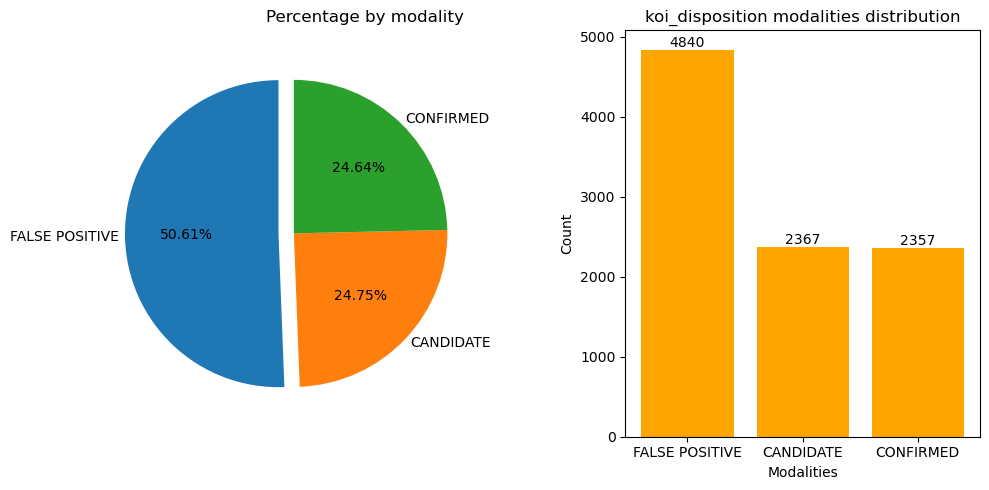

In [10]:
import matplotlib.pyplot as plt

koi_disposition_stats = df_mod_stats.loc[ df_mod_stats["Column name"] == "koi_disposition"]

fig, (pie_p,bar_p) = plt.subplots(nrows=1,ncols=2,figsize=(10,5) )

pie_p.pie(koi_disposition_stats["Percentage of each modality"],
        labels=koi_disposition_stats["Modality name"],
        explode=[0.1,0,0],
        autopct = lambda z: str(round(z, 2)) + '%',
        labeldistance = 1.04, 
        startangle= 90
        )
pie_p.set_title("Percentage by modality",loc="right")
pie_p.axis('equal')

bars = bar_p.bar(koi_disposition_stats["Modality name"],koi_disposition_stats["Count of each modality"],color="orange")
bar_p.set_xlabel("Modalities")
bar_p.set_ylabel("Count")
bar_p.set_title("koi_disposition modalities distribution")

for bar in bars:
    height = bar.get_height()
    bar_p.text(bar.get_x() + bar.get_width() / 2, height, 
             f'{height}', 
             ha='center', va='bottom')

plt.tight_layout(w_pad=5)
plt.show();



La variable `koi_disposition` comporte trois modalités. `FALSE POSITIVE` est majoritaire avec **4 840** observations, soit **50,61 %** du dataset. Les modalités `CANDIDATE` et `CONFIRMED` sont presque équilibrées, avec respectivement **24,75 %** et **24,64 %**, soit une différence de seulement 10 observations.

La classe majoritaire représente donc presque la moitié des observations, tandis que les deux autres représentent chacune environ un quart. La variable cible présente ainsi un déséquilibre modéré.

Ce déséquilibre suggère d’utiliser une séparation stratifiée, une baseline majoritaire et des métriques complémentaires à l’accuracy. Ces choix seront confirmés lors de l’évaluation des modèles.


<a id="univariate-categorical"></a>

#### 8.2 <u>Categorical and binary variables</u>


##### 8.2.1 <u>`koi_pdisposition`:</u>

L’objectif est d’analyser la variable catégorielle `koi_pdisposition`, appelée *Disposition Using Kepler Data*. Elle indique l’explication physique considérée comme la plus probable pour un KOI par le pipeline Kepler, après l’analyse des courbes de lumière et des données des pixels. Ses modalités principales sont `CANDIDATE`, `FALSE POSITIVE` et, éventuellement, `NOT DISPOSITIONED`.

Cette variable est fortement liée à `koi_disposition`, car les catégories `CANDIDATE` et `FALSE POSITIVE` de cette dernière proviennent de la classification fondée sur les données Kepler. Toutefois, les deux variables ne sont pas identiques : `koi_disposition` correspond à la classification enregistrée dans la NASA Exoplanet Archive et reste la variable cible choisie pour ce projet.


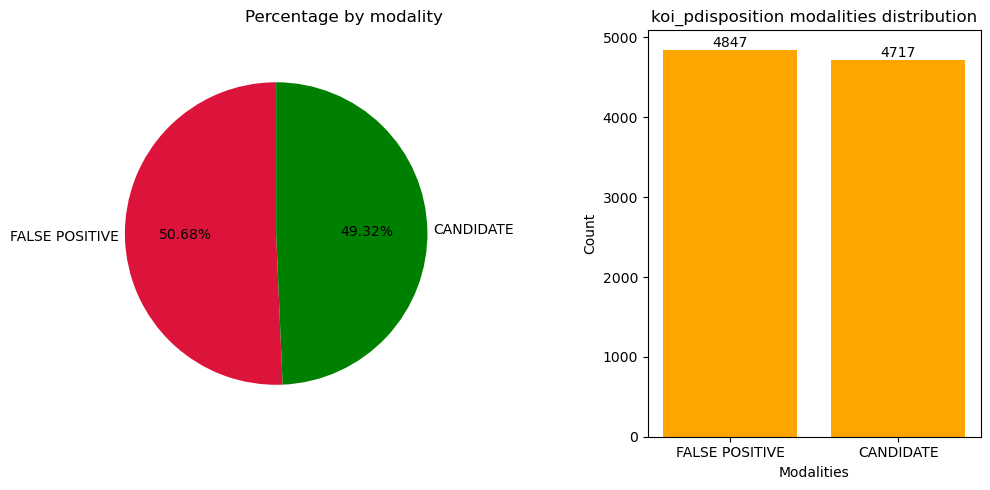

In [11]:
koi_pdisposition_stats= df_mod_stats.loc[ df_mod_stats["Column name"] == "koi_pdisposition"]

fig, (pie_p,bar_p) = plt.subplots(nrows=1,ncols=2,figsize=(10,5) )

pie_p.pie(koi_pdisposition_stats["Percentage of each modality"],
        labels=koi_pdisposition_stats["Modality name"],
        colors=["crimson","green"],
        autopct = lambda z: str(round(z, 2)) + '%',
        labeldistance = 1.04, 
        startangle= 90
        )
pie_p.set_title("Percentage by modality",loc="right")
pie_p.axis('equal')

bars = bar_p.bar(koi_pdisposition_stats["Modality name"],koi_pdisposition_stats["Count of each modality"],color="orange")
bar_p.set_xlabel("Modalities")
bar_p.set_ylabel("Count")
bar_p.set_title("koi_pdisposition modalities distribution")

for bar in bars:
    height = bar.get_height()
    bar_p.text(bar.get_x() + bar.get_width() / 2, height, 
             f'{height}', 
             ha='center', va='bottom')

plt.tight_layout(w_pad=5)
plt.show();


La variable `koi_pdisposition` comporte deux modalités : `FALSE POSITIVE` et `CANDIDATE`. Elles sont presque parfaitement équilibrées, avec respectivement **4 847** observations (**50,68 %**) et **4 717** observations (**49,32 %**). L’écart est de seulement **130** observations, soit **1,36 %**.

Cette variable ne présente donc pas de déséquilibre important entre ses modalités.

<u>**Note:**</u>

Cette analyse décrit uniquement la distribution de `koi_pdisposition`.

<u>**Conclusion:**</u>

Cette variable étant très proche de la cible, son utilisation risque de provoquer une fuite de données. Son exclusion sera décidée lors de la sélection des variables, mais cette proximité justifie d’abord l’étude de sa relation avec `koi_disposition` dans l’analyse bivariée.


##### 8.2.2 <u>`koi_fpflag_nt`:</u>

Nous passons à l’analyse de la variable binaire `koi_fpflag_nt`, car elle contient une valeur incohérente.

<u>**Brief explanation of the variable:**</u>

La variable `koi_fpflag_nt` (*Not Transit-Like Flag*) est un indicateur binaire utilisé dans les données du télescope Kepler pour signaler les signaux dont la forme ne correspond pas à celle d’un transit planétaire.


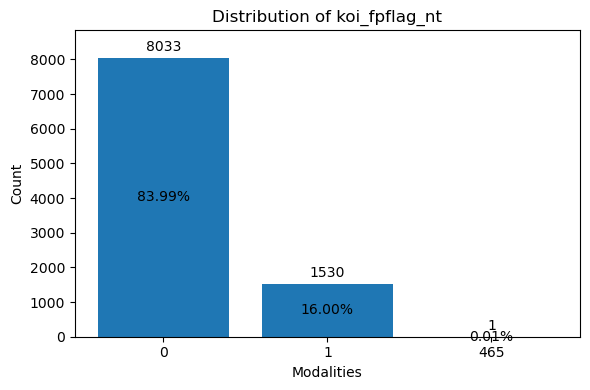

In [12]:
koi_fpflag_nt_stats = df_mod_stats.loc[
    df_mod_stats["Column name"] == "koi_fpflag_nt"
]

modalities = koi_fpflag_nt_stats["Modality name"].astype(str)
counts = koi_fpflag_nt_stats["Count of each modality"]
percentages = koi_fpflag_nt_stats["Percentage of each modality"]

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(modalities, counts)

ax.set_xlabel("Modalities")
ax.set_ylabel("Count")
ax.set_title("Distribution of koi_fpflag_nt")
ax.bar_label(bars, padding=3)
ax.set_ylim(0, counts.max() * 1.1)

for bar, pct in zip(bars, percentages ):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,                             
        f'{pct:.2f}%',                      
        ha='center',                        
        va='center'                         
    )

plt.tight_layout()
plt.show();


La variable `koi_fpflag_nt` est **principalement composée des modalités 0 et 1**, conformément à son **codage binaire attendu**. La **modalité 0 est majoritaire avec 8 033 observations**, tandis que la **modalité 1 apparaît dans 1 530 observations**. Une **valeur 465** apparaît toutefois **une seule fois**. Cette valeur est hors du domaine attendu pour un flag binaire et nécessite donc une vérification particulière. La variable est par ailleurs **fortement déséquilibrée en faveur de la modalité 0**.

<u>**Conclusion:**</u>

La variable est principalement binaire, mais la présence de la valeur incohérente 465 conduira à un traitement spécifique lors du preprocessing.


##### 8.2.3 <u>`koi_fpflag_ss`:</u>

<u>**Brief explanation of the variable:**</u>

La variable `koi_fpflag_ss` (*Stellar Eclipse Flag*) est un indicateur binaire utilisé dans les données du télescope Kepler pour signaler les faux positifs causés par des [`étoiles binaires à éclipses`](#glossaire).


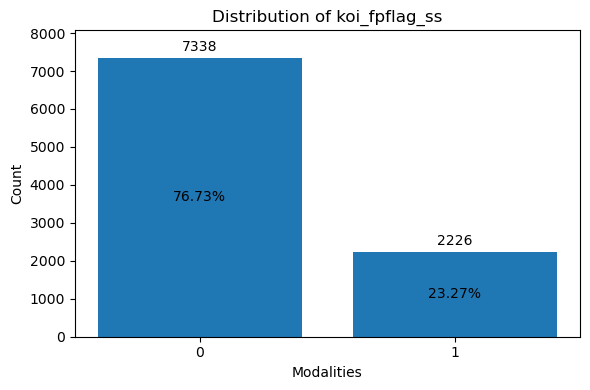

In [13]:
koi_fpflag_ss_stats = df_mod_stats.loc[
    df_mod_stats["Column name"] == "koi_fpflag_ss"
]

modalities = koi_fpflag_ss_stats["Modality name"].astype(str)
counts = koi_fpflag_ss_stats["Count of each modality"]
percentages = koi_fpflag_ss_stats["Percentage of each modality"]

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(modalities, counts)

ax.set_xlabel("Modalities")
ax.set_ylabel("Count")
ax.set_title("Distribution of koi_fpflag_ss")

ax.bar_label(bars, padding=3)
ax.set_ylim(0, counts.max() * 1.1)

for bar, pct in zip(bars, percentages ):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,                             
        f'{pct:.2f}%',                      
        ha='center',                        
        va='center'                         
    )

plt.tight_layout()
plt.show();


La variable `koi_fpflag_ss` possède deux modalités, 0 et 1, conformément à son codage binaire. La modalité 0 est majoritaire avec **7 338** observations, tandis que la modalité 1 représente **2 226** observations.

La variable présente donc un **déséquilibre marqué en faveur de la modalité 0** : celle-ci est environ **3,3 fois plus fréquente que la modalité 1**.


##### 8.2.4 <u>`koi_fpflag_co`:</u>
 
<u>**Brief explanation of the variable:**</u>

La variable `koi_fpflag_co` (Centroid Offset Flag) est un indicateur binaire utilisé dans les données du télescope Kepler pour signaler les faux positifs causés par une [`contamination lumineuse`](#glossaire).

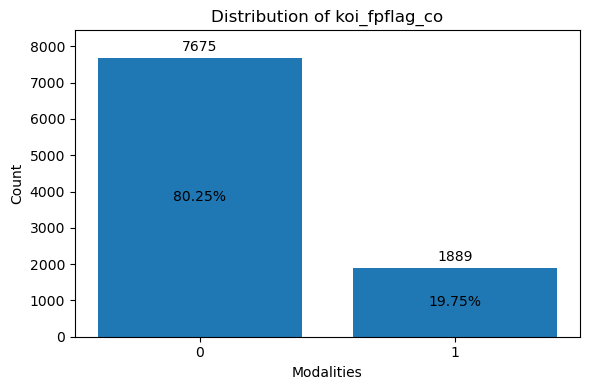

In [14]:
koi_fpflag_co_stats = df_mod_stats.loc[
    df_mod_stats["Column name"] == "koi_fpflag_co"
]

modalities = koi_fpflag_co_stats["Modality name"].astype(str)
counts = koi_fpflag_co_stats["Count of each modality"]
percentages = koi_fpflag_co_stats["Percentage of each modality"]

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(modalities, counts)

ax.set_xlabel("Modalities")
ax.set_ylabel("Count")
ax.set_title("Distribution of koi_fpflag_co")

ax.bar_label(bars, padding=3)
ax.set_ylim(0, counts.max() * 1.1)

for bar, pct in zip(bars, percentages ):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,                             
        f'{pct:.2f}%',                      
        ha='center',                        
        va='center'                         
    )


plt.tight_layout()
plt.show();

La variable `koi_fpflag_co`, également codée en binaire, doit par définition comporter deux modalités, ce qui est bien le cas. La répartition est comparable à celle du flag précédent : **7 675** observations prennent la modalité **0** et **1 889** la modalité **1**. La variable présente donc un **déséquilibre marqué en faveur de la modalité 0**, environ **quatre fois plus fréquente** que la modalité 1. Elle est légèrement plus déséquilibrée que `koi_fpflag_ss`.


##### 8.2.5 <u>`koi_fpflag_ec`:</u>

<u>**Brief explanation of the variable:**</u>

La variable `koi_fpflag_ec` (*Ephemeris Contamination Flag*) est un indicateur binaire utilisé dans les données du télescope Kepler pour signaler les faux positifs causés par une contamination due à une coïncidence de période.


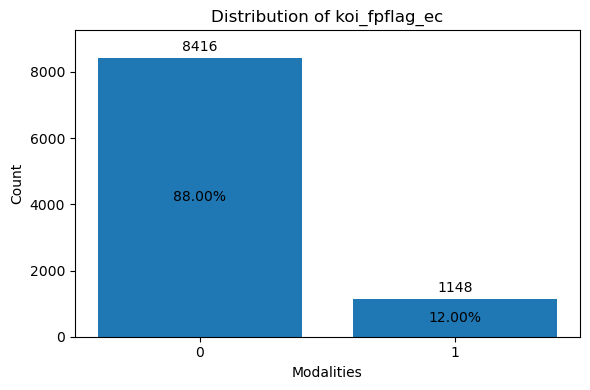

In [15]:
koi_fpflag_ec_stats = df_mod_stats.loc[
    df_mod_stats["Column name"] == "koi_fpflag_ec"
]

modalities = koi_fpflag_ec_stats["Modality name"].astype(str)
counts = koi_fpflag_ec_stats["Count of each modality"]
percentages = koi_fpflag_ec_stats["Percentage of each modality"]
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(modalities, counts)

ax.set_xlabel("Modalities")
ax.set_ylabel("Count")
ax.set_title("Distribution of koi_fpflag_ec")

ax.bar_label(bars, padding=3)
ax.set_ylim(0, counts.max() * 1.1)

for bar, pct in zip(bars, percentages ):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,                             
        f'{pct:.2f}%',                      
        ha='center',                        
        va='center'                         
    )

plt.tight_layout()
plt.show();

La variable `koi_fpflag_ec` est un indicateur binaire et comporte ici les deux modalités attendues : 0 et 1. **La modalité 0** est largement **majoritaire avec 8 416 observations**, contre **1 148 observations pour la modalité 1**. La variable présente donc un **déséquilibre marqué** en **faveur de la modalité 0**, qui est environ **7,3 fois plus fréquente que la modalité 1**.


<u>**Conclusion for `koi_fpflag_ss`, `koi_fpflag_co` and `koi_fpflag_ec`:**</u>

Les variables `koi_fpflag_ss`, `koi_fpflag_co` et `koi_fpflag_ec` comportent uniquement les deux modalités attendues, 0 et 1. Elles présentent toutes un déséquilibre en faveur de la modalité 0 :

- `koi_fpflag_ss` : **76,73 %** de 0 contre **23,27 %** de 1 ;
- `koi_fpflag_co` : **80,25 %** de 0 contre **19,75 %** de 1 ;
- `koi_fpflag_ec` : environ **88 %** de 0 contre **12 %** de 1.

Ce déséquilibre ne constitue pas une anomalie de qualité des données : il décrit simplement la fréquence des différents indicateurs dans le dataset. L’utilité de ces variables pour prédire `koi_disposition` sera vérifiée lors de l’analyse bivariée.


<a id="univariate-quantitative"></a>

#### 8.3 <u>Quantitative variables</u>


<a id="signal-characteristics"></a>

##### 8.3.1 <u>Variables describing signal characteristics</u>


##### 8.3.1.1 <u>`koi_period`:</u>


In [16]:
period = df_kepler["koi_period"]
period.describe()

count      9564.000000
mean         75.671358
std        1334.744046
min           0.241843
25%           2.733684
50%           9.752831
75%          40.715178
max      129995.778400
Name: koi_period, dtype: float64

Les statistiques descriptives montrent déjà l'écart entre la période typique et les valeurs extrêmes. Le graphique suivant utilise une échelle logarithmique afin que les périodes courtes et longues restent visibles simultanément.



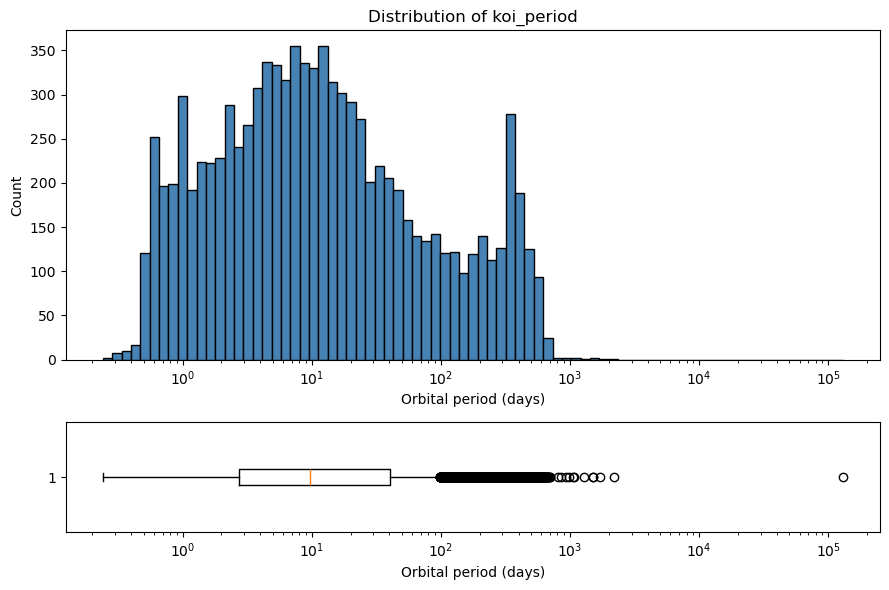

In [17]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    figsize=(9, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

periods_log = np.logspace(
    np.log10(period.min()),
    np.log10(period.max()),
    80
)

ax1.hist(period.dropna(), bins=periods_log, color="steelblue", edgecolor="black")
ax1.set_xscale("log")
ax1.set_title("Distribution of koi_period")
ax1.set_xlabel("Orbital period (days)")
ax1.set_ylabel("Count")

ax2.boxplot(period.dropna(), vert=False)
ax2.set_xlabel("Orbital period (days)")
ax2.set_xscale("log")

plt.tight_layout()
plt.show();

`koi_period` est une variable très **asymétrique à droite**, avec quelques **périodes extrêmement grandes**. La **moyenne** est donc **fortement influencée** par ces valeurs.

La **médiane** est ici **plus représentative** de la **période orbitale typique**.


##### 8.3.1.2 <u>`koi_duration`:</u>



In [18]:
duration = df_kepler["koi_duration"]
duration.describe()

count    9564.000000
mean        5.621606
std         6.471554
min         0.052000
25%         2.437750
50%         3.792600
75%         6.276500
max       138.540000
Name: koi_duration, dtype: float64

La moyenne et la médiane donnent une première indication de l'asymétrie de `koi_duration`. La visualisation permet maintenant de vérifier si cette asymétrie provient de quelques durées extrêmes ou d'une distribution globalement étalée.



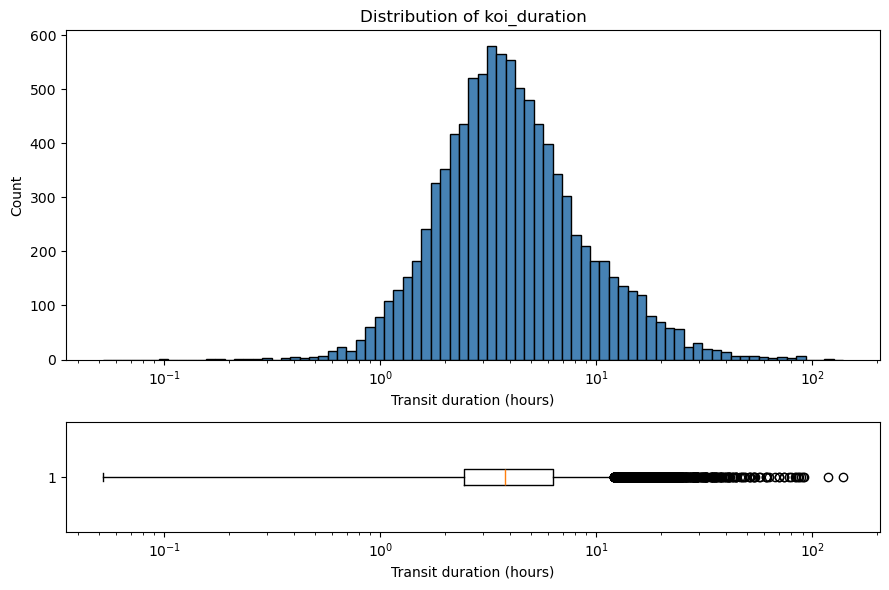

In [19]:


fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    figsize=(9, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

durations_log = np.logspace(
    np.log10(duration.min()),
    np.log10(duration.max()),
    80
)
ax1.hist(duration.dropna(), bins=durations_log, color="steelblue", edgecolor="black")

ax1.set_title("Distribution of koi_duration")
ax1.set_xlabel("Transit duration (hours)")
ax1.set_ylabel("Count")
ax1.set_xscale("log")


ax2.boxplot(duration.dropna(), vert=False)
ax2.set_xlabel("Transit duration (hours)")
ax2.set_xscale("log")


plt.tight_layout()
plt.show();

La **moyenne** de `koi_duration` **(5,62 h)** est supérieure à **la médiane (3,79 h)**, ce qui indique une **asymétrie à droite**. La **majorité des valeurs** se situe **entre 2,44 h et 6,28 h**, comme l’indiquent les quartiles. Le **boxplot** met en évidence plusieurs valeurs atypiques, dont **certaines dépassent 100 heures** et **atteignent 138,54 heures**. Ces valeurs sont **statistiquement atypiques**, mais ne sont pas nécessairement **des erreurs de données**.


##### 8.3.1.3 <u>`koi_depth`:</u> 

In [20]:
depth = df_kepler["koi_depth"]
depth.describe()

count    9.201000e+03
mean     2.379245e+04
std      8.224316e+04
min      0.000000e+00
25%      1.600000e+02
50%      4.210000e+02
75%      1.470000e+03
max      1.540000e+06
Name: koi_depth, dtype: float64

La profondeur du transit contient des valeurs nulles qui ne peuvent pas être représentées sur une échelle logarithmique. Elles sont donc exclues de ce graphique uniquement, tandis qu'elles restent présentes dans le DataFrame pour les décisions ultérieures.



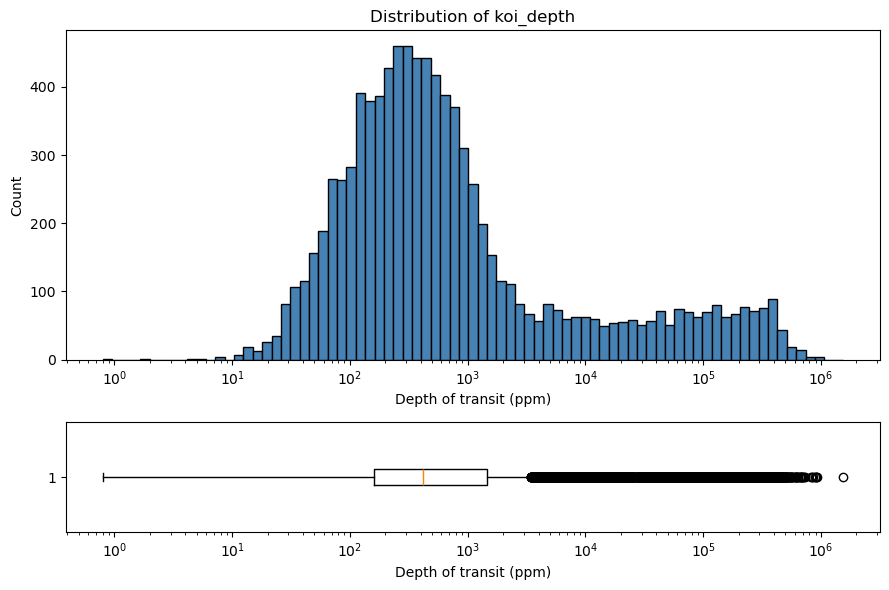

In [21]:

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    figsize=(9, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

depth_cleaned = depth[depth > 0]

depth_log = np.logspace(
    np.log10(depth_cleaned .min()),
    np.log10(depth_cleaned .max()),
    80
) 
ax1.hist(depth_cleaned, bins=depth_log, color="steelblue", edgecolor="black")

ax1.set_title("Distribution of koi_depth")
ax1.set_xlabel("Depth of transit (ppm)")
ax1.set_ylabel("Count")
ax1.set_xscale("log")


ax2.boxplot(depth_cleaned, vert=False)
ax2.set_xlabel("Depth of transit (ppm)")
ax2.set_xscale("log")


plt.tight_layout()
plt.show();

**Note:**

Les valeurs nulles et négatives ont été exclues de l’affichage, car elles ne peuvent pas être représentées sur une échelle logarithmique. Cette exclusion concerne uniquement le graphique et ne signifie pas que les valeurs nulles doivent être supprimées du dataset.


Les résultats montrent une asymétrie fortement positive, causée par une grande différence entre la moyenne et la médiane. La moyenne est environ **56 fois** supérieure à la médiane, avec **23 792,45 ppm** pour la moyenne et **421 ppm** pour la médiane.

On observe également de nombreuses valeurs atypiques ainsi qu’une valeur maximale de **1 540 000 ppm**, ce qui explique la forte asymétrie vers la droite.


##### 8.3.1.4 <u>`koi_model_snr`:</u>

La variable `koi_model_snr` représente **le rapport signal-sur-bruit du modèle de transit** (*Transit Signal-to-Noise Ratio*). Elle **mesure** la **qualité statistique de la détection d’un candidat exoplanétaire** en **comparant** la **profondeur du transit modélisé** au **bruit présent dans les données photométriques**.

Une valeur élevée indique un signal clair et robuste, moins susceptible d’être dû au bruit aléatoire, tandis qu’une valeur faible suggère une détection plus incertaine.


In [22]:
snr_ratio_stats = df_kepler["koi_model_snr"]
snr_ratio_stats.describe()

count    9201.000000
mean      259.895001
std       795.806615
min         0.000000
25%        12.000000
50%        23.000000
75%        78.000000
max      9054.700000
Name: koi_model_snr, dtype: float64

Le résumé statistique suggère une forte asymétrie du SNR. La représentation logarithmique suivante permet de mieux observer la concentration des valeurs usuelles sans laisser les quelques SNR très élevés écraser le graphique.



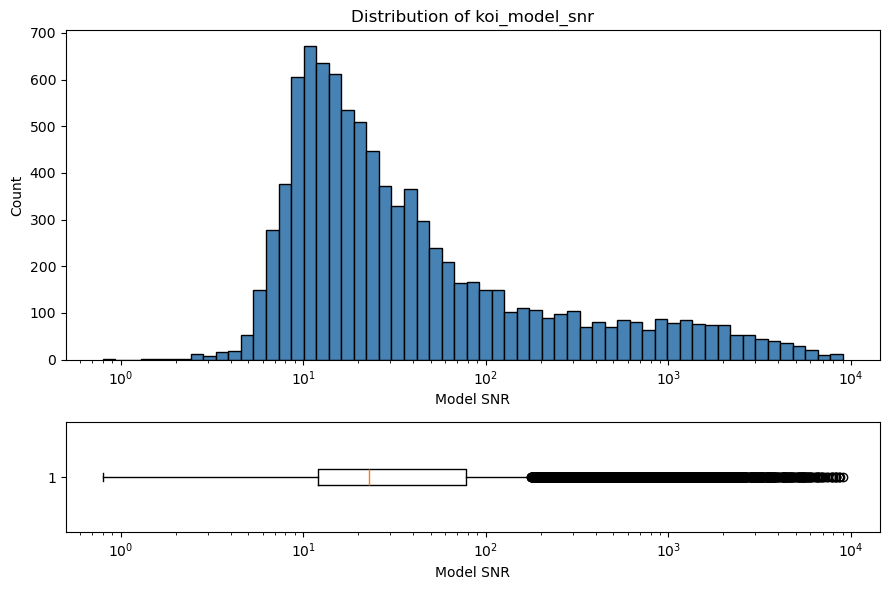

In [23]:

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    figsize=(9, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

snr_ratio_cleaned = snr_ratio_stats[snr_ratio_stats > 0]

snr_ratio_log = np.logspace(
    np.log10(snr_ratio_cleaned.min()),
    np.log10(snr_ratio_cleaned.max()),
    60
) 
ax1.hist(snr_ratio_cleaned.dropna(), bins=snr_ratio_log, color="steelblue", edgecolor="black")

ax1.set_title("Distribution of koi_model_snr")
ax1.set_xlabel("Model SNR")
ax1.set_ylabel("Count")
ax1.set_xscale("log")


ax2.boxplot(snr_ratio_cleaned.dropna(), vert=False)
ax2.set_xlabel("Model SNR")
ax2.set_xscale("log")


plt.tight_layout()
plt.show();

On observe ici une **asymétrie positive**, un peu moins importante que pour la variable précédente. La moyenne de **259,895001** reste toutefois environ **11 fois** supérieure à la médiane, égale à **23**.

Il est donc préférable d’utiliser la médiane pour définir la valeur typique de `koi_model_snr`, plutôt que la moyenne, qui est fortement influencée par les valeurs extrêmes.


<a id="object-characteristics"></a>

#### 8.3.2 <u>Variables describing object characteristics</u>


##### 8.3.2.1 <u>`koi_prad`:</u>

**Brief explanation:**

`koi_prad` correspond à une estimation du rayon de la planète candidate.


In [24]:
planet_radius  = df_kepler["koi_prad"]
planet_radius.describe()

count      9201.000000
mean        102.891778
std        3077.639126
min           0.080000
25%           1.400000
50%           2.390000
75%          14.930000
max      200346.000000
Name: koi_prad, dtype: float64

Les statistiques de `koi_prad` sont dominées par quelques rayons très élevés. Le graphique est construit en échelle logarithmique pour distinguer la population centrale des valeurs extrêmes qui devront être vérifiées.



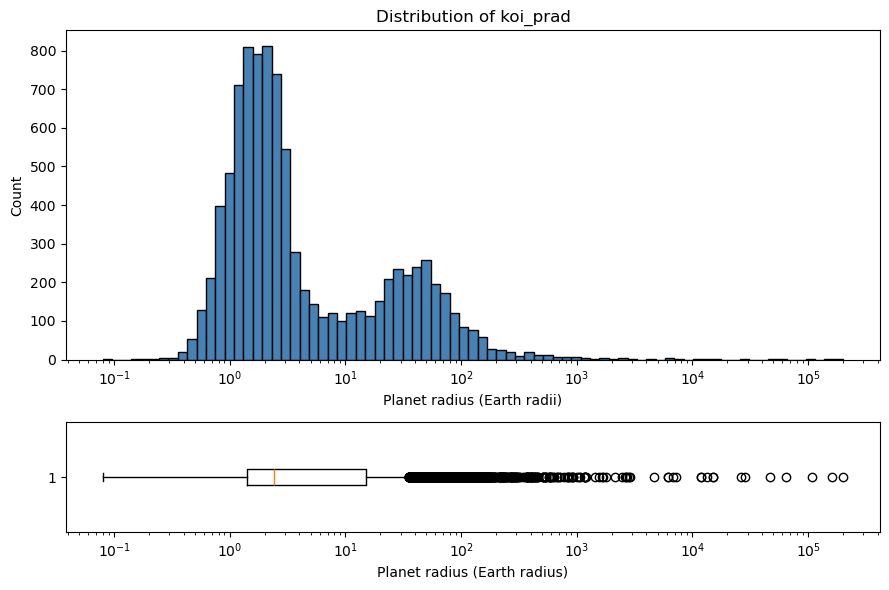

In [25]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    figsize=(9, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)


planet_radius_log = np.logspace(
    np.log10(planet_radius.min()),
    np.log10(planet_radius.max()),
    80
) 

ax1.hist(planet_radius.dropna(), bins=planet_radius_log, color="steelblue", edgecolor="black")

ax1.set_title("Distribution of koi_prad")
ax1.set_xlabel("Planet radius (Earth radii)")
ax1.set_ylabel("Count")
ax1.set_xscale("log")


ax2.boxplot(planet_radius.dropna(), vert=False)
ax2.set_xlabel("Planet radius (Earth radius)")
ax2.set_xscale("log")


plt.tight_layout()
plt.show();

Comme pour les variables précédentes, on observe ici une asymétrie positive extrême. La **moyenne (102,89 rayons terrestres)** est environ **43 fois supérieure à la médiane (2,39 rayons terrestres)**, ce qui rend la moyenne peu représentative de la population typique. La valeur la **plus représentative de ce dataset est donc d’environ 2,4 rayons terrestres**.

Cette **distorsion** est **causée** par **des valeurs extrêmes**, atteignant un **maximum de 200 346 rayons terrestres**. Cette valeur correspond à environ **1 800 rayons solaires**, ce qui est physiquement incompatible avec une planète. Cependant, plutôt que de supprimer immédiatement ces observations, nous vérifierons dans l’analyse bivariée si elles correspondent également à des anomalies sur d’autres paramètres, comme la profondeur du transit.


##### 8.3.2.2 <u>`koi_teq`:</u>

**Brief explanation:**

`koi_teq` correspond à la température d’équilibre théorique de la planète. Il s’agit d’une estimation calculée à partir de la luminosité de l’étoile et de la distance de la planète, en supposant qu’elle absorbe toute la lumière reçue, avec un albédo nul, et qu’elle ne possède pas d’effet de serre.


In [26]:
equilibrium_temp = df_kepler["koi_teq"]


def count_outliers_iqr(series):
    """Compte les valeurs atypiques selon la règle de l'intervalle interquartile.

    Parameters
    ----------
    series : pandas.Series
        Série numérique à analyser.

    Returns
    -------
    int
        Nombre de valeurs inférieures à ``Q1 - 1,5 × IQR`` ou supérieures à
        ``Q3 + 1,5 × IQR``, où ``IQR`` est l'intervalle interquartile.

    Notes
    -----
    Les quantiles de Pandas ignorent les valeurs manquantes. Une valeur
    manquante n'est donc pas comptée comme une valeur atypique.
    """
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()


nb_outliers = count_outliers_iqr(equilibrium_temp)
outliers_percentage = (
    (nb_outliers / equilibrium_temp.count()) * 100
).round(2)

print(f"Count of outliers: {nb_outliers}")
print(f"Percentage of outliers in series: {outliers_percentage}%")

equilibrium_temp.describe()


Count of outliers: 411
Percentage of outliers in series: 4.47%


count     9201.000000
mean      1085.385828
std        856.351161
min         25.000000
25%        539.000000
50%        878.000000
75%       1379.000000
max      14667.000000
Name: koi_teq, dtype: float64

Le nombre de valeurs atypiques a été calculé avec la règle de l'IQR. La visualisation permet de voir leur position dans la distribution de température d'équilibre, sans conclure automatiquement qu'elles sont erronées.



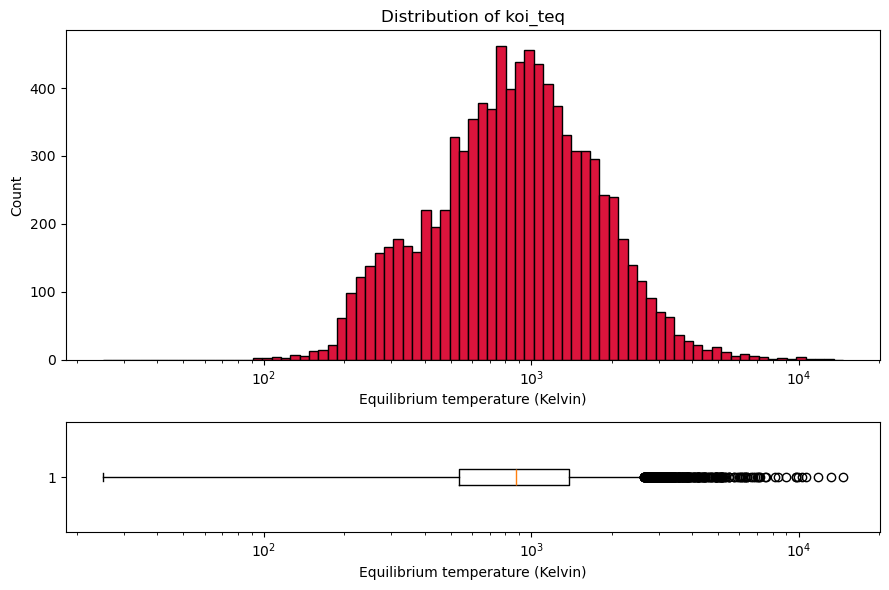

In [27]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    figsize=(9, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)


equilibrium_temp_log = np.logspace(
    np.log10(equilibrium_temp.min()),
    np.log10(equilibrium_temp.max()),
    80
) 

ax1.hist(equilibrium_temp.dropna(), bins=equilibrium_temp_log, color="crimson", edgecolor="black")

ax1.set_title("Distribution of koi_teq")
ax1.set_xlabel("Equilibrium temperature (Kelvin)")
ax1.set_ylabel("Count")
ax1.set_xscale("log")


ax2.boxplot(equilibrium_temp.dropna(), vert=False)
ax2.set_xlabel("Equilibrium temperature (Kelvin)")
ax2.set_xscale("log")


plt.tight_layout()
plt.show();

La distribution de `koi_teq` est **principalement concentrée entre quelques centaines et quelques milliers de kelvins**. La **moyenne (1 085 K)** étant supérieure à la **médiane (878 K)**, la distribution présente une asymétrie positive avec une queue vers les températures élevées. Le boxplot détecte 411 valeurs atypiques, soit **4,47 % des observations**.


##### 8.3.2.3 <u>`koi_insol`:</u>

**Brief explanation:**

`koi_insol` correspond au flux d’insolation reçu par la planète, exprimé en unités du flux reçu par la Terre.

Concrètement, cette valeur indique la quantité d’énergie lumineuse que la planète reçoit de son étoile, comparée à celle que la Terre reçoit du Soleil.

- Une valeur de 1,0 signifie que la planète reçoit exactement la même énergie que la Terre ;
- une valeur de 2,0 signifie qu’elle en reçoit deux fois plus ;
- une valeur de 0,5 signifie qu’elle en reçoit deux fois moins.

Il s’agit d’une mesure de l’éclairement stellaire, calculée à partir de la taille et de la température de l’étoile ainsi que de la distance de la planète.


In [28]:
insolation_ratio = df_kepler["koi_insol"]
insolation_ratio.describe()
insolation_ratio.median()

count    9.243000e+03
mean     7.745737e+03
std      1.592047e+05
min      0.000000e+00
25%      2.015000e+01
50%      1.416000e+02
75%      8.702900e+02
max      1.094755e+07
Name: koi_insol, dtype: float64

141.6

Les valeurs nulles de `koi_insol` sont ignorées uniquement pour construire une échelle logarithmique. Le graphique permet de vérifier visuellement l'asymétrie déjà observée dans les statistiques descriptives.



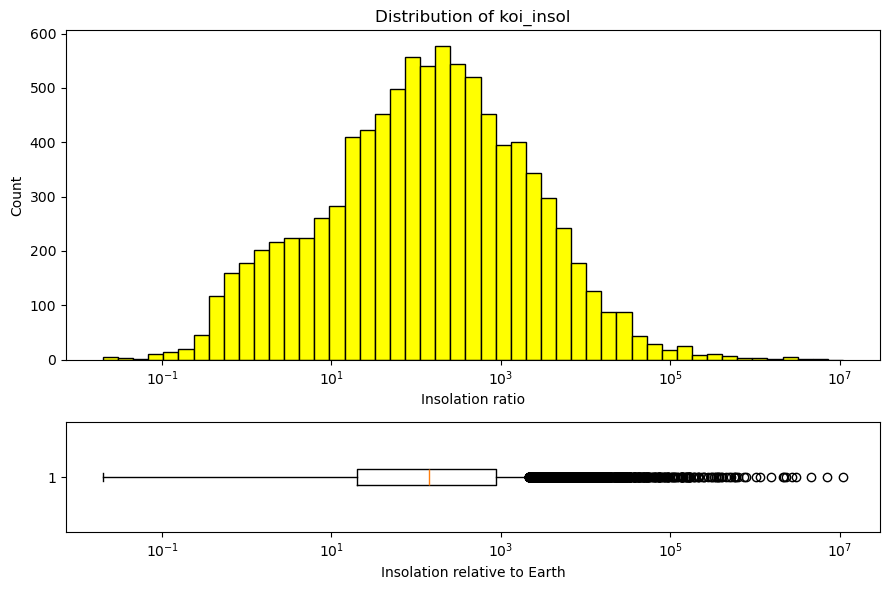

In [29]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    figsize=(9, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

insolation_ratio_cleaned = insolation_ratio[insolation_ratio > 0]
insolation_ratio_log = np.logspace(
    np.log10(insolation_ratio_cleaned.min()),
    np.log10(insolation_ratio_cleaned.max()),
    50
) 

ax1.hist(insolation_ratio_cleaned.dropna(), bins=insolation_ratio_log, color="yellow", edgecolor="black")

ax1.set_title("Distribution of koi_insol")
ax1.set_xlabel("Insolation ratio")
ax1.set_ylabel("Count")
ax1.set_xscale("log")


ax2.boxplot(insolation_ratio_cleaned.dropna(), vert=False)
ax2.set_xlabel("Insolation relative to Earth")
ax2.set_xscale("log")


plt.tight_layout()
plt.show();

La distribution présente **une asymétrie positive marquée** : la **moyenne est fortement supérieure à la médiane en raison de valeurs extrêmes**.

La **médiane de 141,6 signifie que 50 % des objets reçoivent au plus 141,6 fois le flux reçu par la Terre**, tandis que **50 % en reçoivent au moins autant**.


##### 8.3.2.4 <u>`koi_impact`:</u>

`koi_impact` correspond au paramètre d’impact. Il s’agit de la distance projetée sur le ciel entre le centre de l’étoile et le centre de la planète au moment du transit, exprimée en rayons stellaires.

Concrètement, ce paramètre indique à quel endroit la planète traverse le disque de l’étoile :

- une valeur de 0 signifie que la planète passe exactement par le centre de l’étoile, ce qui correspond à un transit central ;
- une valeur proche de 1 signifie que la planète passe près du bord de l’étoile ;
- une valeur supérieure à 1 indique une géométrie atypique qui doit être vérifiée, car elle n’est pas compatible avec un transit central dans l’interprétation simplifiée.

Ce paramètre est important, car il influence la forme et la durée du signal observé : un impact faible produit généralement un transit plus long et en forme de « U », tandis qu’un impact élevé produit un transit plus court et en forme de « V ».


In [30]:
impact = df_kepler["koi_impact"]
impact.describe()

nb_outliers = count_outliers_iqr(impact)
outliers_percentage = ((nb_outliers/impact.count())*100).round(2)

print(f'Count of outliers: {nb_outliers}')
print(f'Percentage of outliers in series: {outliers_percentage}%')


count    9201.000000
mean        0.735105
std         3.348832
min         0.000000
25%         0.197000
50%         0.537000
75%         0.889000
max       100.806000
Name: koi_impact, dtype: float64

Count of outliers: 82
Percentage of outliers in series: 0.89%


Les valeurs d'impact égales à zéro correspondent à une géométrie particulière et ne doivent pas être assimilées à des valeurs manquantes. Elles sont exclues ici uniquement parce qu'un axe logarithmique ne peut pas représenter zéro.



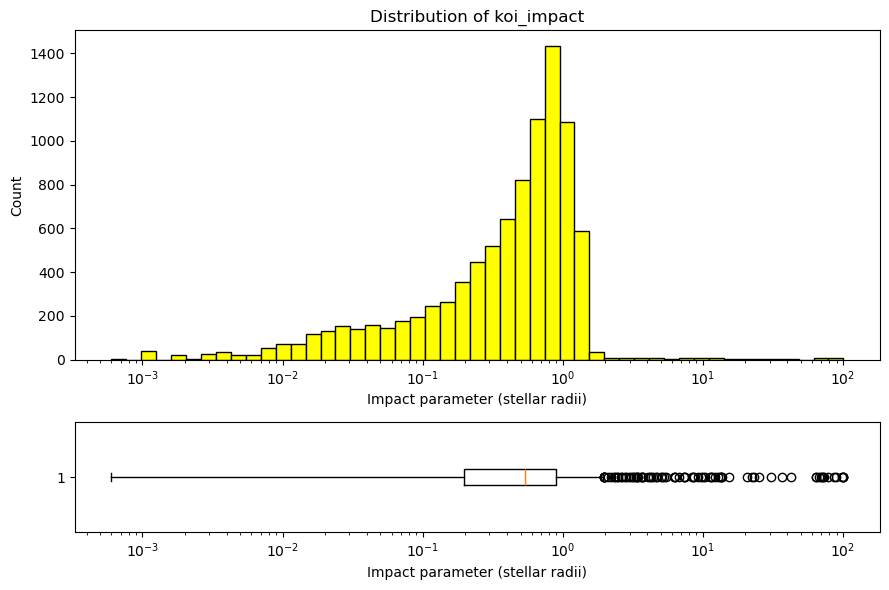

In [31]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    figsize=(9, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

impact_positive = impact[impact > 0].dropna()

impact_log = np.logspace(
    np.log10(impact_positive.min()),
    np.log10(impact_positive.max()),
    50
) 

ax1.hist(impact_positive, bins=impact_log, color="yellow", edgecolor="black")

ax1.set_title("Distribution of koi_impact")
ax1.set_xlabel("Impact parameter (stellar radii)")
ax1.set_ylabel("Count")
ax1.set_xscale("log")

ax2.boxplot(impact_positive, vert=False)
ax2.set_xlabel("Impact parameter (stellar radii)")
ax2.set_xscale("log")


plt.tight_layout()
plt.show();



La variable `koi_impact` présente une asymétrie positive : la moyenne (**0,735**) est supérieure à la médiane (**0,537**), car quelques valeurs très élevées **étirent la distribution vers la droite**.

La majorité des valeurs est inférieure à 1, tandis que le maximum atteint **100,806**. Grâce à la mesure de **l’intervalle interquartile**, on identifie environ **0,89 % de valeurs atypiques**, soit **82 observations**.

**Note**

Les valeurs égales à 0 ont été exclues des graphiques logarithmiques, car le logarithme de 0 n’est pas défini. Elles ne correspondent pas pour autant à des valeurs invalides et restent conservées dans le dataset.


<u>**Conclusion:**</u>

Les variables `koi_prad`, `koi_teq`, `koi_insol` et `koi_impact` décrivent différentes caractéristiques physiques ou géométriques des objets observés : leur taille, leur température d’équilibre, le flux reçu et la géométrie de leur transit.

Elles présentent globalement des distributions asymétriques à droite, avec une majorité d’observations concentrées dans des valeurs relativement faibles et quelques valeurs extrêmes.

Ces valeurs atypiques ne sont pas nécessairement des erreurs, car elles peuvent correspondre à des objets réellement particuliers. Elles devront toutefois être vérifiées et prises en compte lors du preprocessing. Les valeurs manquantes et les valeurs nulles seront également traitées selon la signification propre à chaque variable.


<a id="host-star"></a>

##### 8.3.3 <u>Variables describing the host star</u>


##### 8.3.3.1 <u>`koi_steff`:</u>

In [32]:
stellar_effective_temp = df_kepler["koi_steff"] 

stellar_effective_temp.describe()
stellar_effective_temp.median()



count     9201.000000
mean      5706.823280
std        796.857947
min       2661.000000
25%       5310.000000
50%       5767.000000
75%       6112.000000
max      15896.000000
Name: koi_steff, dtype: float64

5767.0

La distribution de `koi_steff` est maintenant visualisée après exclusion des valeurs manquantes pour le graphique. Cette étape permet de vérifier la légère asymétrie observée dans les statistiques avant de quantifier les valeurs atypiques.



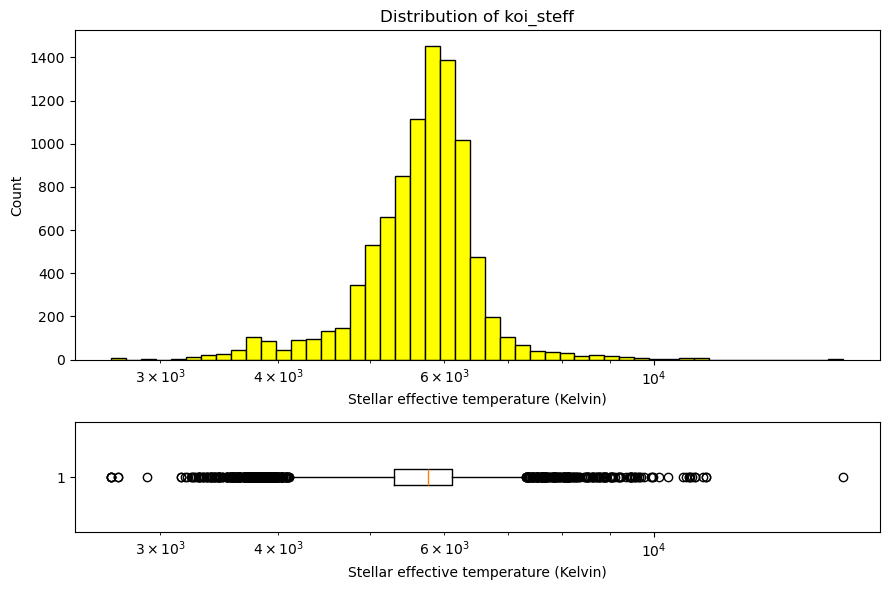

In [33]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    figsize=(9, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)


stellar_effective_temp_clean = stellar_effective_temp.dropna()


stellar_ef_temp_log = np.logspace(
    np.log10(stellar_effective_temp_clean.min()),
    np.log10(stellar_effective_temp_clean.max()),
    50
) 

ax1.hist(stellar_effective_temp_clean, bins=stellar_ef_temp_log, color="yellow", edgecolor="black")

ax1.set_title("Distribution of koi_steff")
ax1.set_xlabel("Stellar effective temperature (Kelvin)")
ax1.set_ylabel("Count")
ax1.set_xscale("log")


ax2.boxplot(stellar_effective_temp_clean,vert=False)
ax2.set_xlabel("Stellar effective temperature (Kelvin)")
ax2.set_xscale("log")

plt.tight_layout()
plt.show();



La fonction suivante quantifie les valeurs atypiques de `koi_steff` avec la règle de l'intervalle interquartile. Cette mesure complète le graphique, mais ne suffit pas à elle seule pour décider de supprimer ces observations.



In [34]:
def outliers_values(series):
    """Retourne les bornes de l'IQR et les effectifs des valeurs atypiques.

    Parameters
    ----------
    series : pandas.Series
        Série numérique à analyser.

    Returns
    -------
    tuple
        Tuple composé de la borne inférieure, de la borne supérieure, du
        nombre de valeurs inférieures à la borne inférieure et du nombre de
        valeurs supérieures à la borne supérieure.

    Notes
    -----
    Les bornes sont calculées avec la règle usuelle de l'intervalle
    interquartile : ``Q1 - 1,5 × IQR`` et ``Q3 + 1,5 × IQR``.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    lower_count = (series < lower).sum()
    upper_count = (series > upper).sum()

    return lower, upper, lower_count, upper_count


lower, upper, lower_count, upper_count = outliers_values(
    stellar_effective_temp
)

total_outliers = lower_count + upper_count

percentage_lower = (lower_count / total_outliers * 100).round(2)
percentage_upper = (upper_count / total_outliers * 100).round(2)

print(f"Lower outliers: {lower_count} ({percentage_lower}%)")
print(f"Upper outliers: {upper_count} ({percentage_upper}%)")

print(f"Atypical values < {lower} kelvins")
print(f"Atypical values > {upper} kelvins")


Lower outliers: 344 (62.32%)
Upper outliers: 208 (37.68%)
Atypical values < 4107.0 kelvins
Atypical values > 7315.0 kelvins


La variable `koi_steff` contient **9 201** observations, avec **363 valeurs manquantes**. La **moyenne (5 706,82 K)** est **légèrement inférieure à la médiane (5 767 K)**, ce qui suggère une **légère asymétrie vers la gauche**. La moitié des températures stellaires se situe **entre 5 310 K et 6 112 K**. La **règle de l’IQR** considère comme **atypiques les valeurs inférieures à 4 107 K ou supérieures à 7 315 K**.


##### 8.3.3.2 <u>`koi_slogg`:</u>

**Brief explanation:**

`koi_slogg` représente la gravité de surface de l’étoile hôte, exprimée sous la forme de son logarithme en base 10 : `log10(g)`, en `log10(cm/s²)`.


In [35]:
log10_stars_gravity = df_kepler["koi_slogg"] 
log10_stars_gravity.describe()

count    9201.000000
mean        4.310157
std         0.432606
min         0.047000
25%         4.218000
50%         4.438000
75%         4.543000
max         5.364000
Name: koi_slogg, dtype: float64

`koi_slogg` est déjà exprimée sur une échelle logarithmique. Le graphique est donc présenté sans appliquer une seconde transformation logarithmique, afin de conserver l'interprétation physique de la variable.



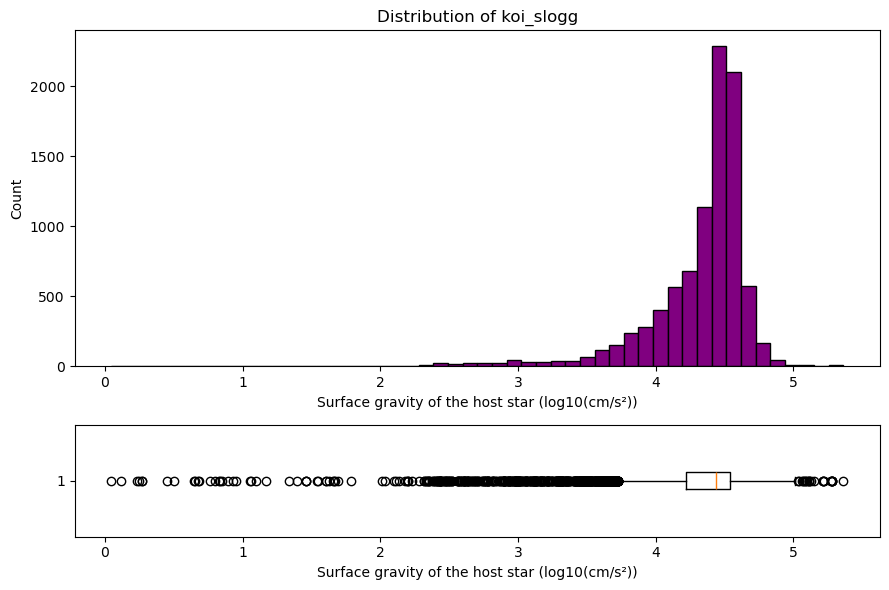

In [36]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    figsize=(9, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

log10_stars_gravity = log10_stars_gravity.dropna()

ax1.hist(log10_stars_gravity, bins=50, color="purple", edgecolor="black")
ax1.set_title("Distribution of koi_slogg")
ax1.set_xlabel("Surface gravity of the host star (log10(cm/s²))")
ax1.set_ylabel("Count")


ax2.boxplot(log10_stars_gravity,vert=False)
ax2.set_xlabel("Surface gravity of the host star (log10(cm/s²))")

plt.tight_layout()
plt.show();


La distribution présente une asymétrie négative, ce qui indique que la **médiane (4,438000 log10(cm/s²))** est supérieure à la **moyenne (4,310157 log10(cm/s²))**.


Les fonctions communes sont maintenant disponibles : les prochains graphiques pourront utiliser la même convention de couleurs et les mêmes règles de représentation. Je commence par comparer la décision préliminaire à la décision finale.



##### 8.3.3.3 <u>`koi_srad`:</u>

In [37]:
stars_radius =  df_kepler["koi_srad"]
stars_radius.describe()

count    9201.000000
mean        1.728712
std         6.127185
min         0.109000
25%         0.829000
50%         1.000000
75%         1.345000
max       229.908000
Name: koi_srad, dtype: float64

Les statistiques de `koi_srad` indiquent une asymétrie positive. L'échelle logarithmique permet de représenter simultanément les rayons stellaires usuels et les étoiles de très grand rayon.



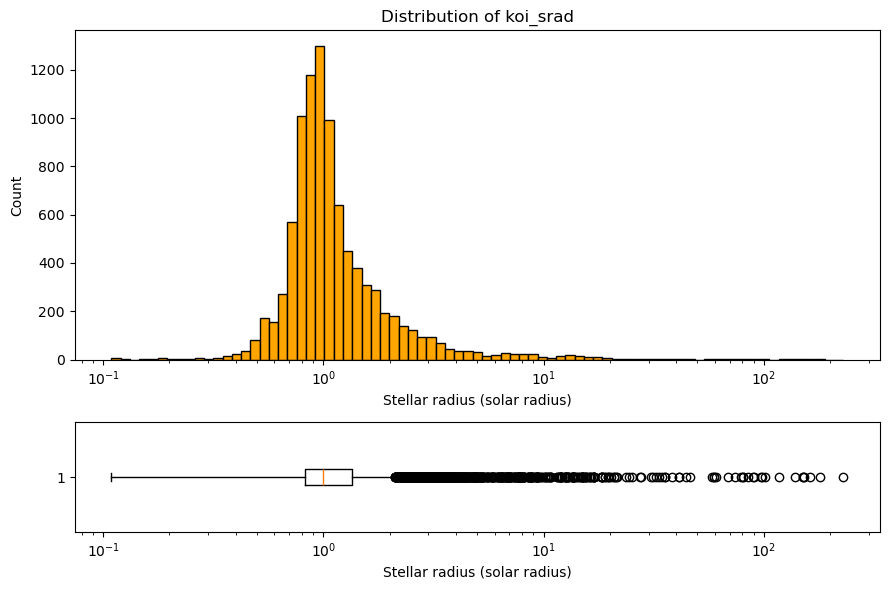

In [71]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    figsize=(9, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

stars_radius = stars_radius.dropna()

stars_radius_log = np.logspace(
    np.log10(stars_radius.min()),
    np.log10(stars_radius.max()),
    80
) 

ax1.hist(stars_radius, bins=stars_radius_log, color="orange", edgecolor="black")
ax1.set_title("Distribution of koi_srad")
ax1.set_xlabel("Stellar radius (solar radius)")
ax1.set_ylabel("Count")
ax1.set_xscale("log")

ax2.boxplot(stars_radius, vert=False)
ax2.set_xlabel("Stellar radius (solar radius)")
ax2.set_xscale("log")


plt.tight_layout()
plt.show();

On observe une asymétrie positive, due à une **moyenne (1,728712 R☉)** supérieure à la **médiane (1 R☉)**.

La médiane indique qu’au moins **50 % des étoiles du dataset ont un rayon inférieur ou égal à celui du Soleil**, tandis que les **50 % restantes ont un rayon supérieur ou égal**.

Dans l’analyse bivariée, nous observerons la relation entre les valeurs atypiques de `koi_srad` et `koi_model_snr`, ainsi que l’influence possible de la taille de l’étoile hôte sur la qualité du signal.


##### 8.3.3.4 <u>`koi_kepmag`:</u>

In [39]:
kepler_magnitude_stars = df_kepler["koi_kepmag"]
kepler_magnitude_stars.describe()



count    9563.000000
mean       14.264606
std         1.385448
min         6.966000
25%        13.440000
50%        14.520000
75%        15.322000
max        20.003000
Name: koi_kepmag, dtype: float64

La magnitude de Kepler est une échelle logarithmique inversée : une faible valeur correspond à une étoile plus brillante. Le graphique permet de vérifier la concentration des magnitudes sans interpréter cette variable comme une luminosité linéaire.



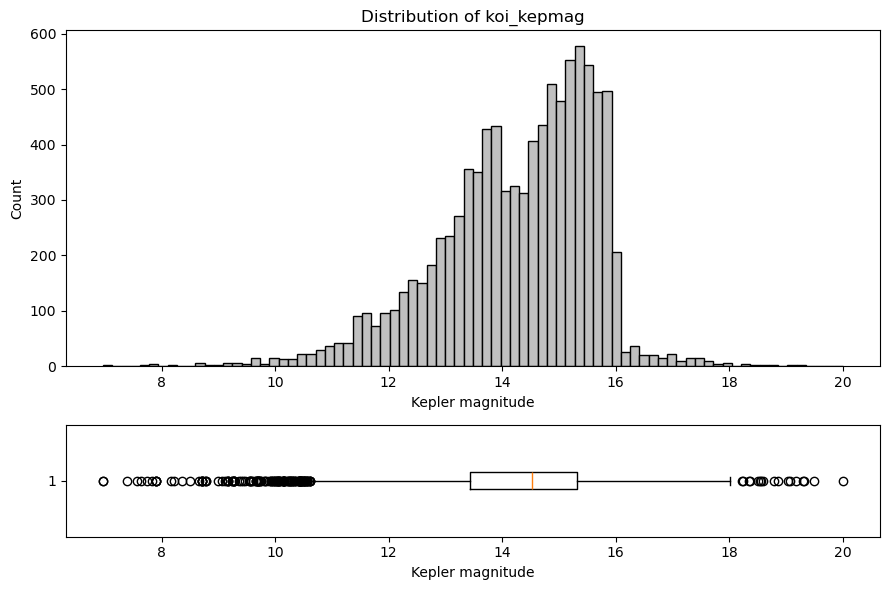

In [40]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    figsize=(9, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

kepler_magnitude_stars = kepler_magnitude_stars.dropna()

ax1.hist(kepler_magnitude_stars, bins=80, color="silver", edgecolor="black")
ax1.set_title("Distribution of koi_kepmag")
ax1.set_xlabel("Kepler magnitude")
ax1.set_ylabel("Count")

ax2.boxplot(kepler_magnitude_stars, vert=False)
ax2.set_xlabel("Kepler magnitude")

plt.tight_layout()
plt.show();

On retrouve une distribution plus ou moins centrée, mais tout de même caractérisée par une **faible asymétrie négative**. La différence entre la **moyenne (14,26)** et la **médiane (14,52)** de la magnitude de Kepler est de **0,26**. Les 50 % centraux des observations se situent entre **13,44 et 15,32 Kp**, tandis que les valeurs s’étendent de **6,966 à 20,003 Kp**.

Je rappelle que la magnitude est une échelle inversée : une magnitude de Kepler plus faible correspond à une étoile observée plus brillante. C’est ce qui justifie l’étude de son lien avec `koi_model_snr`.


<a id="bivariate"></a>

### 9. <u>Bivariate analysis</u>

<a id="bivariate-one-variable"></a>

#### 9.1 <u>Target variable versus another variable</u>


Avant de comparer les relations bivariées, je définis un ordre et des couleurs identiques pour les trois classes. Les fonctions suivantes centralisent également le nettoyage nécessaire aux nuages de points logarithmiques afin de rendre les comparaisons cohérentes.



In [41]:
target_order = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

target_colors = {
    "CANDIDATE": "green",
    "CONFIRMED": "royalblue",
    "FALSE POSITIVE": "crimson"
}


def get_positive_pair(x, y):
    """Extrait une paire de variables numériques positive avec la cible.

    Parameters
    ----------
    x, y : str
        Noms des deux colonnes numériques à conserver.

    Returns
    -------
    pandas.DataFrame
        DataFrame contenant ``x``, ``y`` et ``koi_disposition`` après
        remplacement des infinis par des valeurs manquantes, suppression des
        lignes incomplètes et conservation des valeurs strictement positives
        de ``x`` et ``y``.

    Notes
    -----
    Les valeurs nulles sont exclues par cette fonction uniquement parce que
    les graphiques logarithmiques utilisés ensuite ne peuvent pas les
    représenter. Cela ne signifie pas qu'elles doivent être supprimées du
    dataset original.
    """
    pair = df_kepler[[x, y, "koi_disposition"]].copy()
    pair = pair.replace([np.inf, -np.inf], np.nan).dropna()
    pair = pair[(pair[x] > 0) & (pair[y] > 0)]
    return pair


def draw_scatter(
    pair,
    x,
    y,
    title,
    xlabel,
    ylabel,
    log_x=False,
    log_y=False
):
    """Trace un nuage de points coloré selon la décision finale.

    Parameters
    ----------
    pair : pandas.DataFrame
        DataFrame contenant les deux variables à représenter et la colonne
        ``koi_disposition``.
    x, y : str
        Noms des colonnes utilisées sur les axes horizontal et vertical.
    title, xlabel, ylabel : str
        Titre du graphique et étiquettes des axes.
    log_x, log_y : bool, default=False
        Indique s'il faut utiliser une échelle logarithmique sur chaque axe.

    Returns
    -------
    None
        Affiche le graphique et ne retourne pas de valeur.

    Notes
    -----
    La fonction utilise les variables globales ``target_order`` et
    ``target_colors`` pour conserver les mêmes modalités et les mêmes
    couleurs dans tous les graphiques bivariés.
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.scatterplot(
        data=pair,
        x=x,
        y=y,
        hue="koi_disposition",
        hue_order=target_order,
        palette=target_colors,
        alpha=0.35,
        s=20,
        ax=ax
    )

    if log_x:
        ax.set_xscale("log")

    if log_y:
        ax.set_yscale("log")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(
        title="Final disposition",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()


Les fonctions communes sont maintenant disponibles : les prochains graphiques pourront utiliser la même convention de couleurs et les mêmes règles de représentation. Je commence par comparer la décision préliminaire à la décision finale.



##### 9.1.1 <u>`koi_disposition` × `koi_pdisposition`</u>

In [42]:
koi_disposition = df_kepler["koi_disposition"]
koi_pdisposition = df_kepler["koi_pdisposition"]

crosstab_p_and_disposition_pct = pd.crosstab(
    koi_disposition,
    koi_pdisposition,
    normalize="index"
) * 100

crosstab_p_and_disposition_pct

koi_pdisposition,CANDIDATE,FALSE POSITIVE
koi_disposition,,
CANDIDATE,100.000000,0.000000
CONFIRMED,99.660585,0.339415
FALSE POSITIVE,0.020661,99.979339


Le tableau croisé calcule les proportions conditionnelles pour chaque classe finale. La heatmap suivante rend cette concordance plus lisible et permet d'identifier rapidement les modalités les plus représentées.



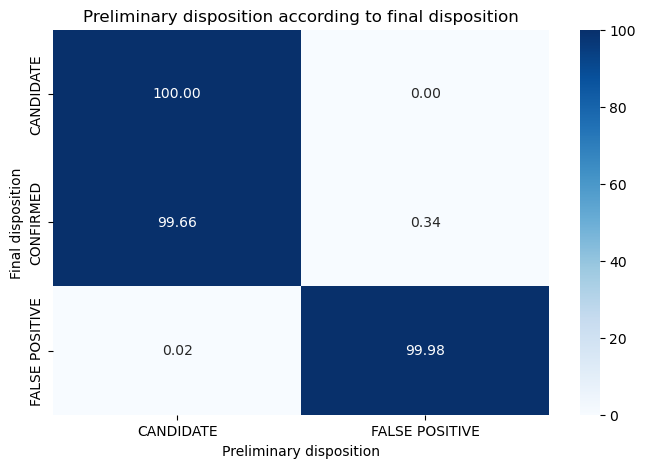

In [43]:
crosstab_pdisposition = pd.crosstab(
    df_kepler["koi_disposition"],
    df_kepler["koi_pdisposition"],
    normalize="index"
) * 100

crosstab_pdisposition = crosstab_pdisposition.reindex(
    index=target_order,
    columns=["CANDIDATE", "FALSE POSITIVE"],
    fill_value=0
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    crosstab_pdisposition,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.xlabel("Preliminary disposition")
plt.ylabel("Final disposition")
plt.title("Preliminary disposition according to final disposition")
plt.show();

La matrice montre une très forte concordance entre la décision finale (`koi_disposition`) et la décision préliminaire (`koi_pdisposition`). Les objets finalement classés `CANDIDATE` avaient tous été préalablement classés `CANDIDATE`. Parmi les objets **`CONFIRMED`, 99,66 %** avaient également été classés `CANDIDATE`, tandis que **0,34 %** avaient été initialement considérés comme **FALSE POSITIVE**. Enfin, **99,98 %** des objets finalement classés `FALSE POSITIVE` avaient déjà été identifiés comme tels lors de l’analyse préliminaire.

Cette relation indique que la décision préliminaire est fortement liée à la décision finale. Elle permet surtout d’opposer les objets rejetés comme faux positifs aux objets non rejetés, mais elle différencie très peu les `CANDIDATE` des `CONFIRMED`.

Lors de la sélection des variables, `koi_pdisposition` sera probablement supprimée, car elle est trop liée à la variable cible `koi_disposition`. Elle pourrait provoquer une fuite de données et gonfler artificiellement les performances du modèle.


<u>**Global view of target with numeric variables**</u>

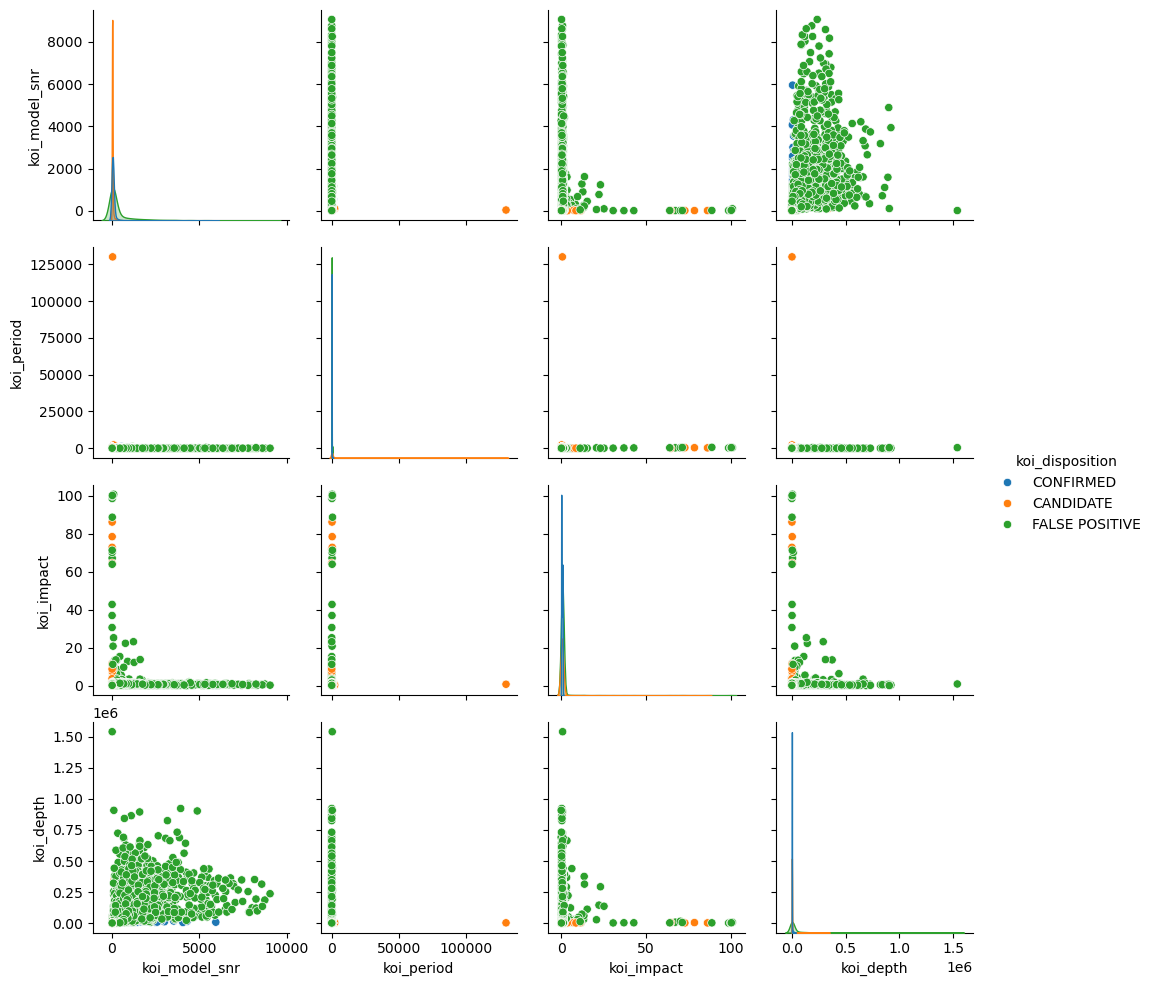

In [44]:
sns.pairplot(df_kepler, vars=["koi_model_snr","koi_period","koi_impact","koi_depth"], hue="koi_disposition")

Le pairplot donne une vue générale des distributions et des relations entre les variables sélectionnées. Toutefois, la présence de valeurs extrêmes et la superposition des observations limitent sa lisibilité. Des analyses graphiques séparées sont donc nécessaires pour interpréter chaque relation plus précisément.


##### 9.1.2 <u>`koi_disposition` × `koi_model_snr`</u>

In [45]:
df_kepler.groupby("koi_disposition")["koi_model_snr"].describe()

,count,mean,std,min,25%,50%,75%,max
koi_disposition,,,,,,,,
CANDIDATE,2262.0,30.375597,86.130716,0.0,9.2,11.9,18.2,1441.9
CONFIRMED,2356.0,86.682216,280.438690,5.9,20.2,31.4,54.4,5945.9
FALSE POSITIVE,4583.0,462.221471,1070.108392,0.0,12.6,34.2,294.1,9054.7


Les statistiques du SNR par classe donnent les médianes et la dispersion nécessaires pour compléter la visualisation. Le violon plot suivant utilise `log1p` afin de conserver les zéros tout en réduisant l'effet des valeurs très élevées.



C:\Users\willi\AppData\Local\Temp\ipykernel_2908\3907580204.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


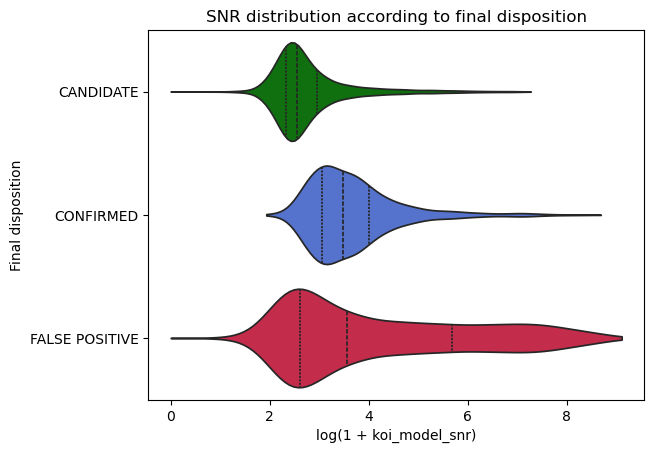

In [46]:
snr_plot = df_kepler[
    ["koi_model_snr", "koi_disposition"]
].copy()

snr_plot = snr_plot.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

snr_plot = snr_plot[
    snr_plot["koi_model_snr"] >= 0
]

snr_plot["snr_log1p"] = np.log1p(
    snr_plot["koi_model_snr"]
)

sns.violinplot(
    data=snr_plot,
    x="snr_log1p",
    y="koi_disposition",
    order=target_order,
    inner="quart",
    cut=0,
    density_norm="width",
    palette=target_colors
)

plt.xlabel("log(1 + koi_model_snr)")
plt.ylabel("Final disposition")
plt.title("SNR distribution according to final disposition")
plt.show();

`koi_model_snr` est associé à `koi_disposition`, mais cette relation n’est pas monotone. Les `CANDIDATE` présentent généralement **les SNR les plus faibles**, tandis que les `FALSE POSITIVE` ont la **médiane et la dispersion les plus élevées**. Un **SNR élevé** ne **signifie donc pas** nécessairement **qu’un objet est `CONFIRMED`**. Cette **variable est informative**, mais **ne suffit pas seule** à déterminer la **décision finale**.


##### 9.1.3 <u>`koi_disposition` × `koi_period`</u>

In [47]:
df_kepler.groupby("koi_disposition")["koi_period"].describe()

,count,mean,std,min,25%,50%,75%,max
koi_disposition,,,,,,,,
CANDIDATE,2367.0,144.992449,2674.896026,0.259820,5.910014,17.504417,91.137832,129995.778400
CONFIRMED,2357.0,27.706884,54.492454,0.341842,5.144365,11.448658,25.961901,1071.232624
FALSE POSITIVE,4840.0,65.127814,131.486003,0.241843,1.387046,5.243875,36.280198,1064.268096


Les statistiques de `koi_period` indiquent un chevauchement entre les classes et des valeurs extrêmes. Le graphique en échelle logarithmique permet de comparer les distributions sans être dominé par la période maximale.



C:\Users\willi\AppData\Local\Temp\ipykernel_2908\4275726556.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0.5, 0, 'Orbital period (days)')

Text(0, 0.5, 'Final disposition')

Text(0.5, 1.0, 'Orbital period according to final disposition')

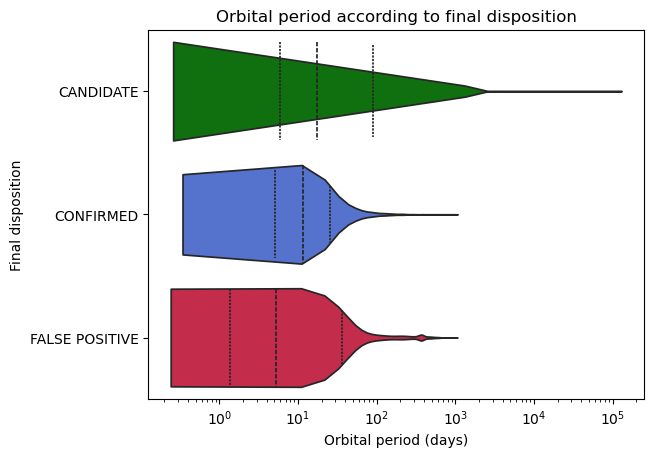

In [48]:
period_plot = df_kepler[
    ["koi_period", "koi_disposition"]
].copy()

period_plot = period_plot.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

period_plot = period_plot[
    period_plot["koi_period"] > 0
]

ax = sns.violinplot(
    data=period_plot,
    x="koi_period",
    y="koi_disposition",
    order=target_order,
    inner="quart",
    cut=0,
    density_norm="width",
    palette=target_colors
)

ax.set_xscale("log")

plt.xlabel("Orbital period (days)")
plt.ylabel("Final disposition")
plt.title("Orbital period according to final disposition")
plt.show()

La période orbitale semble être associée à la décision finale, car les trois classes ne présentent pas exactement les mêmes distributions. Les `FALSE POSITIVE` présentent notamment une concentration particulière pour les périodes inférieures à un jour, tandis que les `CANDIDATE` possèdent une distribution plus étendue. Cependant, le chevauchement important entre les classes montre que `koi_period` ne **permet pas**, **à elle seule**, de **distinguer suffisamment** les **trois modalités**. Cette **variable** sera donc **conservée** comme **variable potentiellement informative**, mais devra **être combinée** à **d’autres caractéristiques**.

##### 9.1.4 <u>`koi_fpflag_*` × `koi_disposition`</u>

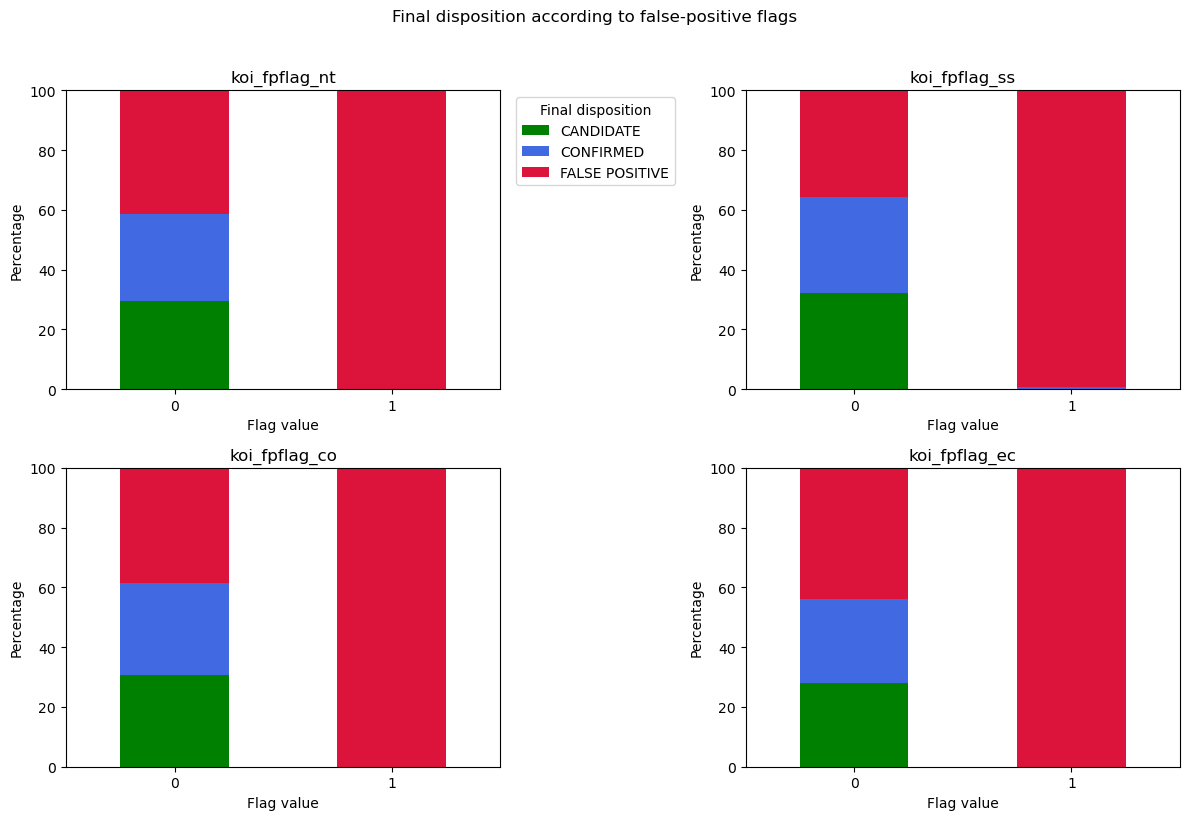

In [49]:
flag_columns = [
    "koi_fpflag_nt",
    "koi_fpflag_ss",
    "koi_fpflag_co",
    "koi_fpflag_ec"
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8)
)

for i, (ax, flag_column) in enumerate(
    zip(axes.flat, flag_columns)
):

    flag_values = df_kepler[flag_column].copy()

    if flag_column == "koi_fpflag_nt":
        flag_values = flag_values.replace(465, 0)

    flag_target_pct = pd.crosstab(
        flag_values,
        df_kepler["koi_disposition"],
        normalize="index"
    ) * 100

    flag_target_pct = flag_target_pct.reindex(
        columns=target_order,
        fill_value=0
    )

    flag_target_pct.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[target_colors[col] for col in target_order],
        legend=(i == 0)
    )

    ax.set_title(flag_column)
    ax.set_xlabel("Flag value")
    ax.set_ylabel("Percentage")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=0)

    if i == 0:
        ax.legend(
            title="Final disposition",
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

plt.suptitle(
    "Final disposition according to false-positive flags",
    y=1.02
)

plt.tight_layout()
plt.show();

Les flags présentent un pouvoir discriminant important, particulièrement lorsqu’ils prennent la valeur 1, qui est fortement associée à la classe `FALSE POSITIVE`. Ils seront conservés comme variables candidates après correction de la valeur 465. Leur influence devra toutefois être surveillée, car ils proviennent eux-mêmes du processus de validation des signaux.


##### 9.1.5 <u>`koi_disposition` × `koi_impact`</u>

C:\Users\willi\AppData\Local\Temp\ipykernel_2908\3504985807.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


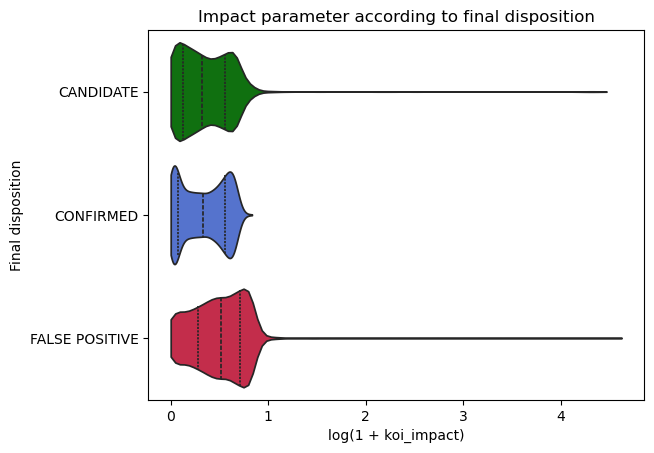

In [50]:
impact_plot = df_kepler[
    ["koi_impact", "koi_disposition"]
].copy()

impact_plot = impact_plot.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

impact_plot = impact_plot[
    impact_plot["koi_impact"] >= 0
]

impact_plot["impact_log1p"] = np.log1p(
    impact_plot["koi_impact"]
)

sns.violinplot(
    data=impact_plot,
    x="impact_log1p",
    y="koi_disposition",
    order=target_order,
    inner="quart",
    cut=0,
    density_norm="width",
    palette=target_colors
)

plt.xlabel("log(1 + koi_impact)")
plt.ylabel("Final disposition")
plt.title("Impact parameter according to final disposition")
plt.show();

`koi_impact` semble informative pour **différencier partiellement les faux positifs des autres classes**. Les **zéros doivent être conservés** car ils **peuvent représenter des transits centraux** et **ne sont pas des valeurs manquantes**. Les **valeurs extrêmes devront être traitées** avec une **transformation `log1p` ou une méthode robuste**.


##### 9.1.6 <u>`koi_disposition` × `koi_depth`</u>

C:\Users\willi\AppData\Local\Temp\ipykernel_2908\523318074.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


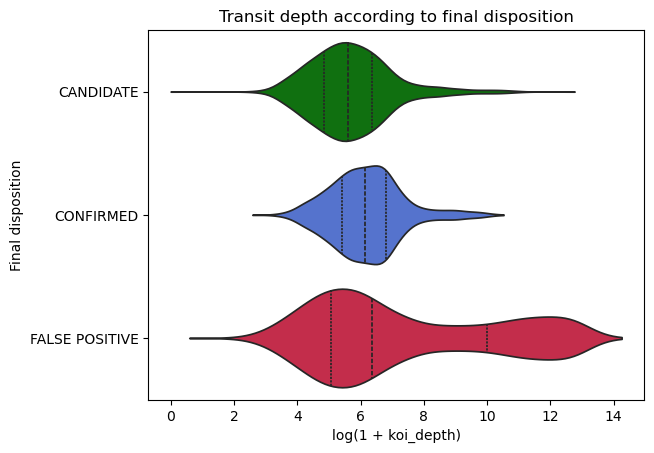

In [51]:
depth_plot = df_kepler[
    ["koi_depth", "koi_disposition"]
].copy()

depth_plot = depth_plot.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

depth_plot = depth_plot[
    depth_plot["koi_depth"] >= 0
]

depth_plot["depth_log1p"] = np.log1p(
    depth_plot["koi_depth"]
)

sns.violinplot(
    data=depth_plot,
    x="depth_log1p",
    y="koi_disposition",
    order=target_order,
    inner="quart",
    cut=0,
    density_norm="width",
    palette=target_colors
)

plt.xlabel("log(1 + koi_depth)")
plt.ylabel("Final disposition")
plt.title("Transit depth according to final disposition")
plt.show();

`koi_depth` présente **une relation potentielle avec la cible**, principalement en raison de la **forte dispersion** des `FALSE POSITIVE`. La variable sera conservée, mais sa **forte asymétrie** et ses **valeurs extrêmes** justifient l’utilisation de **`log1p`**. Les **valeurs nulles** sont **conservées** dans le dataset et ne sont exclues que des graphiques logarithmiques classiques.


##### 9.1.7 <u>`koi_disposition` × `kepler_name`</u>

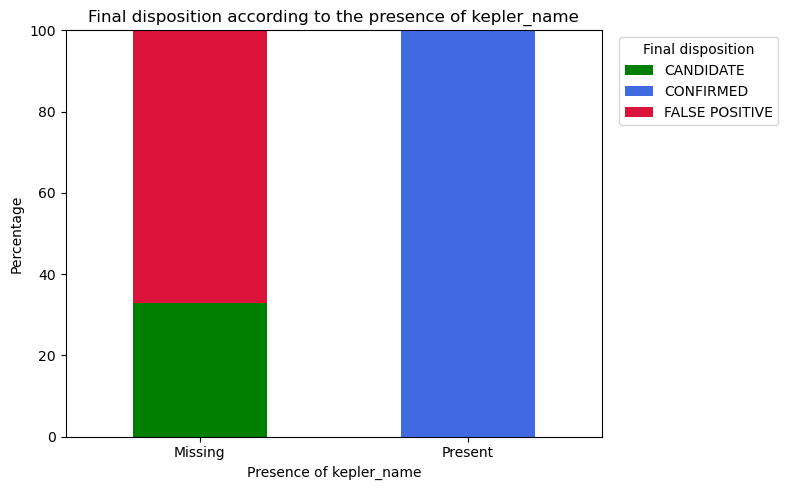

In [52]:
name_status = np.where(
    df_kepler["kepler_name"].notna(),
    "Present",
    "Missing"
)

name_target_pct = pd.crosstab(
    name_status,
    df_kepler["koi_disposition"],
    normalize="index"
) * 100

name_target_pct = name_target_pct.reindex(
    index=["Missing", "Present"],
    columns=target_order,
    fill_value=0
)

ax = name_target_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=[target_colors[col] for col in target_order]
)

ax.set_xlabel("Presence of kepler_name")
ax.set_ylabel("Percentage")
ax.set_ylim(0, 100)
ax.set_title("Final disposition according to the presence of kepler_name")
ax.legend(title="Final disposition",
          bbox_to_anchor=(1.02, 1),
          loc="upper left")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show();

`kepler_name` et même son **indicateur de présence** sont **des variables fortement liées à la cible**. Leur utilisation permettrait au modèle de récupérer indirectement le résultat de la classification. Ces variables seront donc exclues afin d’éviter une fuite de données.


##### 9.1.8 <u>`koi_disposition` × `koi_teq`</u>

C:\Users\willi\AppData\Local\Temp\ipykernel_2908\1186187743.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


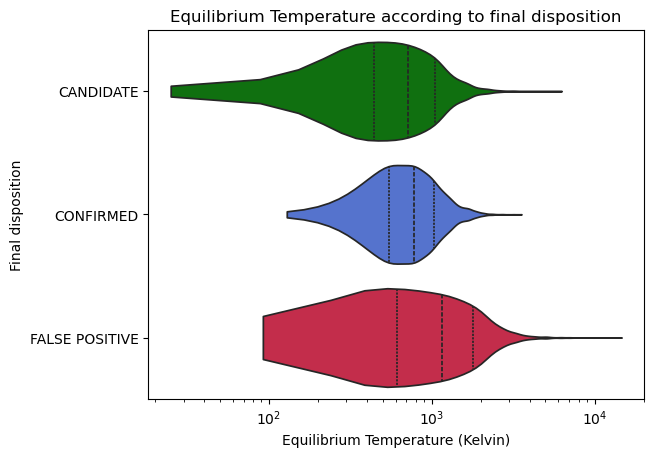

In [53]:
teq_plot = df_kepler[
    ["koi_teq", "koi_disposition"]
].copy()

teq_plot = teq_plot.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

teq_plot = teq_plot[
teq_plot["koi_teq"] > 0
]

ax = sns.violinplot(
    data=teq_plot,
    x="koi_teq",
    y="koi_disposition",
    order=target_order,
    inner="quart",
    cut=0,
    density_norm="width",
    palette=target_colors
)

ax.set_xscale("log")

plt.xlabel("Equilibrium Temperature (Kelvin)")
plt.ylabel("Final disposition")
plt.title("Equilibrium Temperature according to final disposition")
plt.show();

Les `FALSE POSITIVE` présentent globalement des **températures d'équilibre plus élevées** et surtout **plus dispersées**. Les `CONFIRMED` sont davantage **concentrés autour de valeurs intermédiaires**, tandis que les `CANDIDATE` présentent une **distribution plus étendue**. Il existe néanmoins un **fort chevauchement entre les trois classes**

##### 9.1.9 <u>`koi_disposition` × `koi_insol`</u>

C:\Users\willi\AppData\Local\Temp\ipykernel_2908\763643757.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


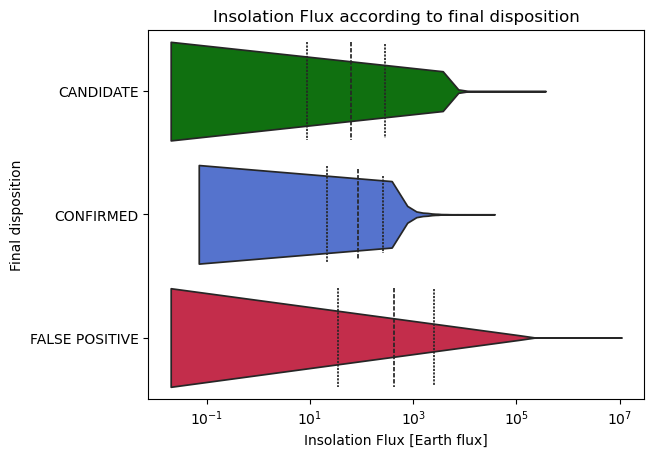

In [62]:
insol_plot = df_kepler[
    ["koi_insol", "koi_disposition"]
].copy()

insol_plot = insol_plot.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

insol_plot = insol_plot[
    insol_plot["koi_insol"] > 0
]

ax = sns.violinplot(
    data=insol_plot,
    x="koi_insol",
    y="koi_disposition",
    order=target_order,
    inner="quart",
    cut=0,
    density_norm="width",
    palette=target_colors
)

ax.set_xscale("log")

plt.xlabel("Insolation Flux [Earth flux]")
plt.ylabel("Final disposition")
plt.title("Insolation Flux according to final disposition")
plt.show();

On retrouve une tendance similaire : `les FALSE POSITIVE` s'étendent vers des **valeurs d'insolation beaucoup plus élevées**, alors que `CONFIRMED` et `CANDIDATE` sont davantage **concentrés dans les faibles valeurs**. Là encore, les classes présentent **un chevauchement important**.


##### 9.1.10 <u> `koi_disposition` x `koi_prad` </u>


C:\Users\willi\AppData\Local\Temp\ipykernel_2908\1259202848.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


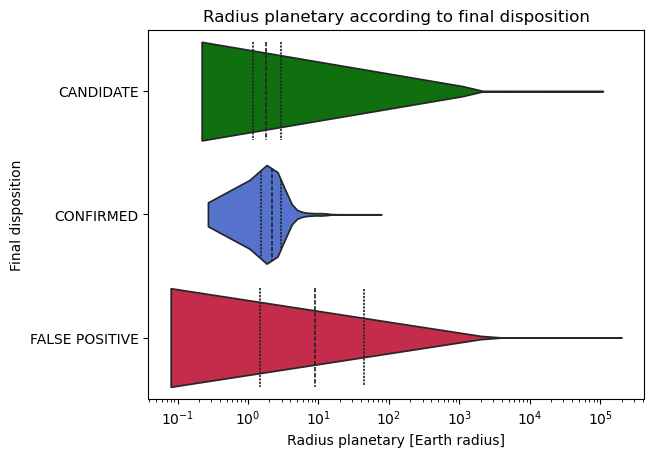

In [63]:
prad_plot = df_kepler[
    ["koi_prad", "koi_disposition"]
].copy()

prad_plot = prad_plot.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

prad_plot = prad_plot[
    prad_plot["koi_prad"] > 0
]

ax = sns.violinplot(
    data=prad_plot,
    x="koi_prad",
    y="koi_disposition",
    order=target_order,
    inner="quart",
    cut=0,
    density_norm="width",
    palette=target_colors
)

ax.set_xscale("log")

plt.xlabel("Radius planetary [Earth radius]")
plt.ylabel("Final disposition")
plt.title("Radius planetary according to final disposition")
plt.show();

Les **trois classes** présentent un **chevauchement important**. **Cependant**, les objets `CONFIRMED` ont **des rayons planétaires estimés beaucoup plus concentrés**, **principalement autour de quelques rayons terrestres**, tandis que les `CANDIDATE` et surtout les` FALSE POSITIVE` présentent des **distributions beaucoup plus étendues** vers **les grands rayons**. `koi_prad` apporte donc une **information discriminante**, **sans permettre** à elle **seule** de **séparer les classes.**

##### 9.1.11 <u> `koi_disposition` x `koi_steff` </u>

C:\Users\willi\AppData\Local\Temp\ipykernel_2908\991275353.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


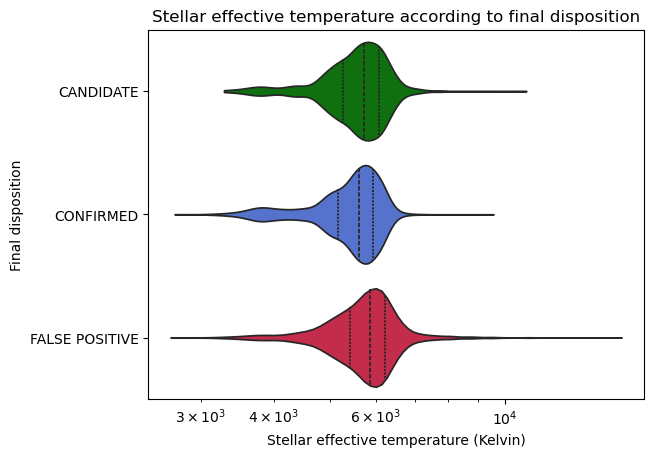

In [64]:
steff_plot = df_kepler[
    ["koi_steff", "koi_disposition"]
].copy()

steff_plot = steff_plot.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

steff_plot = steff_plot[
    steff_plot["koi_steff"] > 0
]

ax = sns.violinplot(
    data=steff_plot,
    x="koi_steff",
    y="koi_disposition",
    order=target_order,
    inner="quart",
    cut=0,
    density_norm="width",
    palette=target_colors
)

ax.set_xscale("log")

plt.xlabel("Stellar effective temperature (Kelvin)")
plt.ylabel("Final disposition")
plt.title("Stellar effective temperature according to final disposition")
plt.show();

Les **trois classes** sont **principalement concentrées** autour de **températures similaires**, avec un fort chevauchement. Les `FALSE POSITIVE` semblent légèrement décalés vers des **températures plus élevées**, mais la **séparation reste faible**.

##### 9.1.12 <u> `koi_disposition` x `koi_slogg` </u>

C:\Users\willi\AppData\Local\Temp\ipykernel_2908\730963235.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


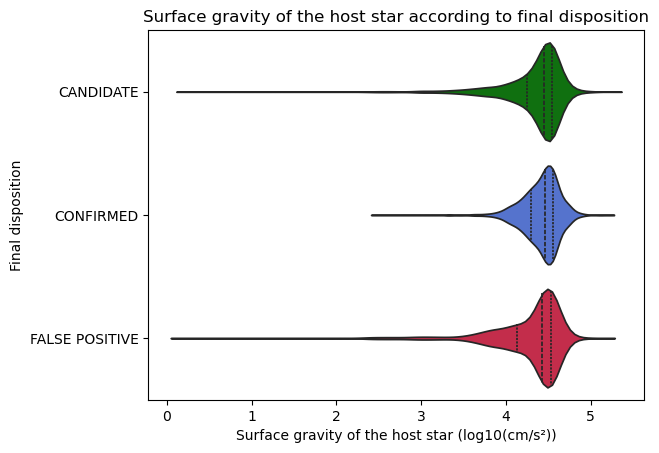

In [67]:
slogg_plot = df_kepler[
    ["koi_slogg", "koi_disposition"]
].copy()

ax = sns.violinplot(
    data=slogg_plot,
    x="koi_slogg",
    y="koi_disposition",
    order=target_order,
    inner="quart",
    cut=0,
    density_norm="width",
    palette=target_colors
)


plt.xlabel("Surface gravity of the host star (log10(cm/s²))")
plt.ylabel("Final disposition")
plt.title("Surface gravity of the host star according to final disposition")
plt.show();

C’est encore plus net : les trois distributions sont très fortement superposées, avec des valeurs centrales extrêmement proches. Les différences concernent surtout les queues de distribution

##### 9.1.13 <u> `koi_disposition` x `koi_kepmag` </u>

C:\Users\willi\AppData\Local\Temp\ipykernel_2908\3824407782.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


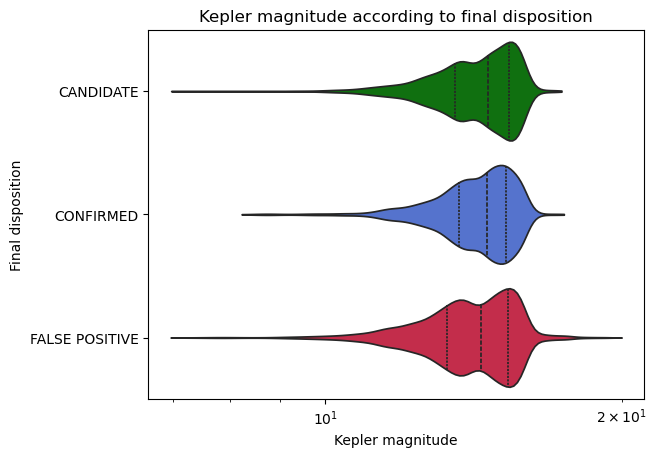

In [72]:
kepmag_plot = df_kepler[
    ["koi_kepmag", "koi_disposition"]
].copy()

kepmag_plot = kepmag_plot.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()


ax = sns.violinplot(
    data=kepmag_plot,
    x="koi_kepmag",
    y="koi_disposition",
    order=target_order,
    inner="quart",
    cut=0,
    density_norm="width",
    palette=target_colors
)

ax.set_xscale("log")

plt.xlabel("Kepler magnitude")
plt.ylabel("Final disposition")
plt.title("Kepler magnitude according to final disposition")
plt.show();

Il existe **toujours un chevauchement important**, mais la distribution des `FALSE POSITIVE` semble légèrement différente de celles des `CONFIRMED` et `CANDIDATE`. La variable possède donc **un faible signal discriminant**, sans séparation nette.

##### 9.1.14 <u> `koi_disposition` x `koi_srad` </u>


C:\Users\willi\AppData\Local\Temp\ipykernel_2908\3986302909.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


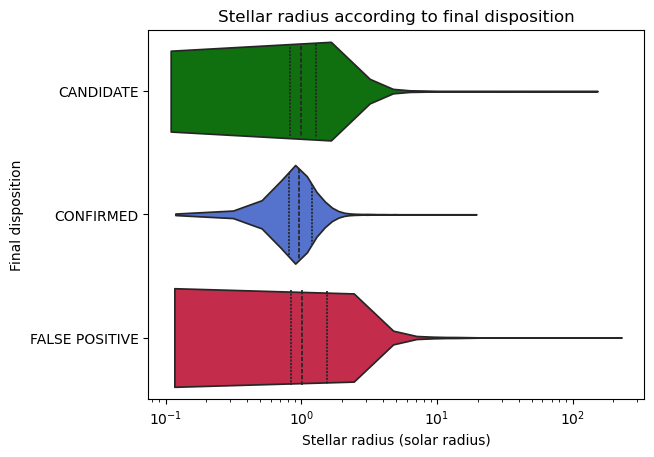

In [73]:
srad_plot = df_kepler[
    ["koi_srad", "koi_disposition"]
].copy()

srad_plot = srad_plot.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

 
ax = sns.violinplot(
    data=srad_plot,
    x="koi_srad",
    y="koi_disposition",
    order=target_order,
    inner="quart",
    cut=0,
    density_norm="width",
    palette=target_colors
)

ax.set_xscale("log")

plt.xlabel("Stellar radius (solar radius)")
plt.ylabel("Final disposition")
plt.title("Stellar radius according to final disposition")
plt.show();

Les **distributions se chevauchent fortement**, mais les `CONFIRMED` sont **beaucoup plus concentrés autour d’une plage restreinte**, tandis que les `CANDIDATE` et `FALSE POSITIVE` présentent des **distributions plus étendues et davantage de valeurs extrêmes.**

<a id="bivariate-two-variables"></a>

#### 9.2 <u>Two explanatory variables together</u>


##### 9.2.1 <u> `koi_prad` x `koi_depth` : </u>

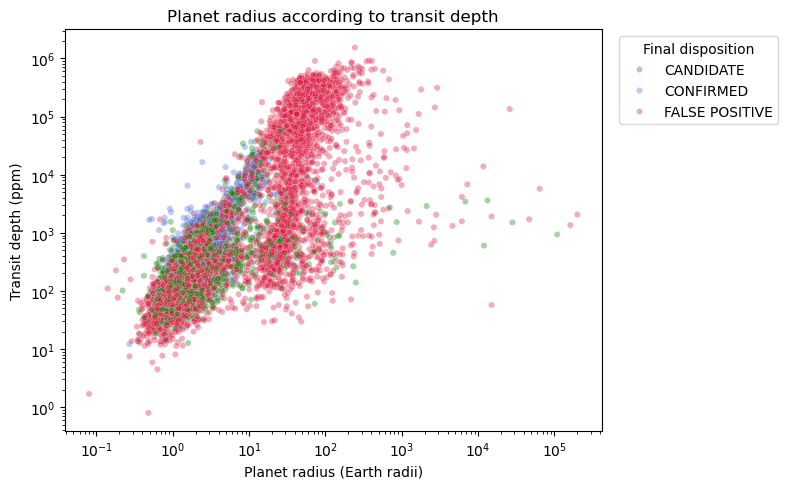

In [55]:
pair = get_positive_pair(
    "koi_prad",
    "koi_depth"
)

draw_scatter(
    pair,
    x="koi_prad",
    y="koi_depth",
    title="Planet radius according to transit depth",
    xlabel="Planet radius (Earth radii)",
    ylabel="Transit depth (ppm)",
    log_x=True,
    log_y=True
)

`koi_prad` et `koi_depth` présentent **une relation positive et partiellement redondante**. Cette **relation est physiquement cohérente**, mais elle indique que **les deux variables** ne fournissent pas nécessairement des **informations totalement indépendantes**. Elles seront conservées provisoirement et leur utilité sera vérifiée lors de la sélection des variables.


##### 9.2.2 <u> `koi_insol` x `koi_teq` : </u>

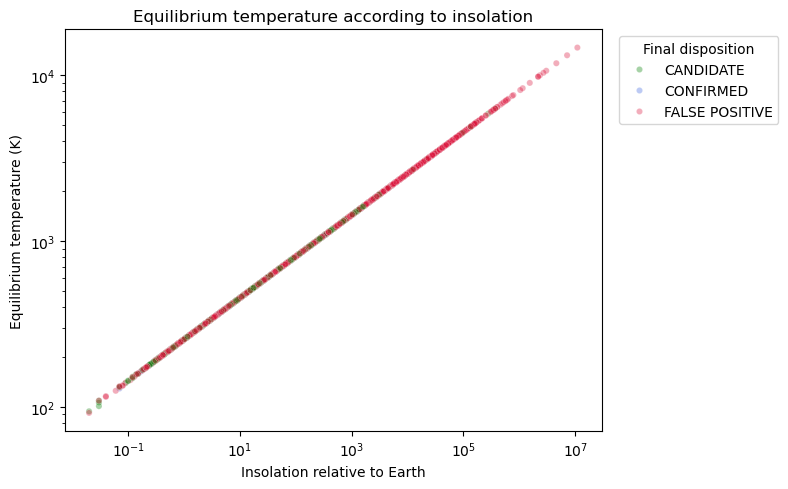

In [56]:
pair = get_positive_pair(
    "koi_insol",
    "koi_teq"
)

draw_scatter(
    pair,
    x="koi_insol",
    y="koi_teq",
    title="Equilibrium temperature according to insolation",
    xlabel="Insolation relative to Earth",
    ylabel="Equilibrium temperature (K)",
    log_x=True,
    log_y=True
)

`koi_insol` et `koi_teq` sont **très fortement liées**. Cette **relation est cohérente avec leur définition physique et suggère une redondance entre les deux variables**. Elles seront conservées à ce stade, mais pourront faire l’objet d’une sélection ultérieure afin de **limiter les informations répétées**.


##### 9.2.3 <u> `koi_steff` x `koi_teq` : </u>

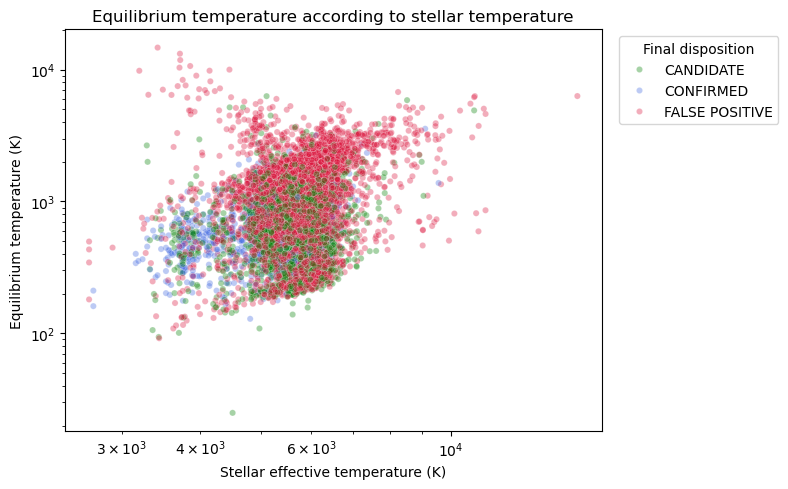

In [57]:
pair = get_positive_pair(
    "koi_steff",
    "koi_teq"
)

draw_scatter(
    pair,
    x="koi_steff",
    y="koi_teq",
    title="Equilibrium temperature according to stellar temperature",
    xlabel="Stellar effective temperature (K)",
    ylabel="Equilibrium temperature (K)",
    log_x=True,
    log_y=True
)

`koi_steff` présente une **relation positive mais diffuse** avec `koi_teq`. Cette **variable peut apporter une information complémentaire sur l’étoile hôte**, mais elle **ne permet pas à elle seule de distinguer les classes**. Elle sera **conservée provisoirement** et **traitée lors du preprocessing**.


##### 9.2.4 <u> `koi_impact` x `koi_duration `: </u>

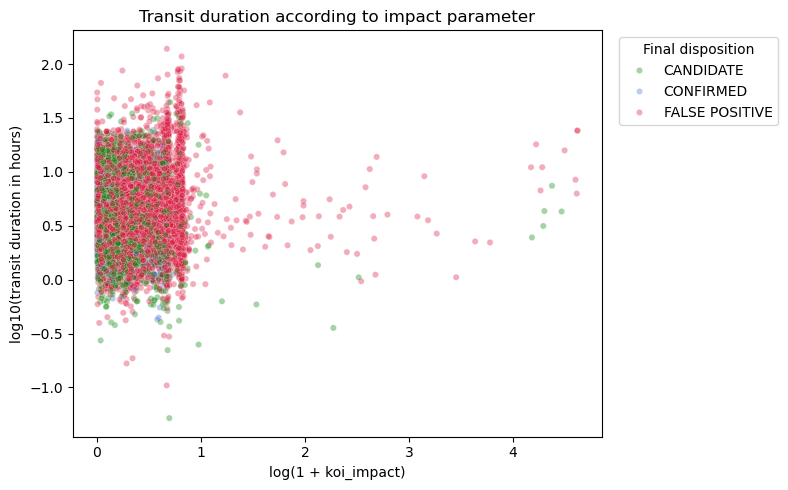

In [58]:
pair = df_kepler[
    ["koi_impact", "koi_duration", "koi_disposition"]
].copy()

pair = pair.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

pair = pair[
    (pair["koi_impact"] >= 0) &
    (pair["koi_duration"] > 0)
]

pair["impact_log1p"] = np.log1p(
    pair["koi_impact"]
)

pair["duration_log10"] = np.log10(
    pair["koi_duration"]
)

draw_scatter(
    pair,
    x="impact_log1p",
    y="duration_log10",
    title="Transit duration according to impact parameter",
    xlabel="log(1 + koi_impact)",
    ylabel="log10(transit duration in hours)"
)

La relation entre `koi_impact` et `koi_duration` ne semble pas suffisamment simple ou forte pour permettre une distinction directe des classes. Ces deux variables seront conservées, car leur interaction pourrait néanmoins être exploitée par des modèles non linéaires.


##### 9.2.5 <u> `koi_slogg` x `koi_srad` : </u>

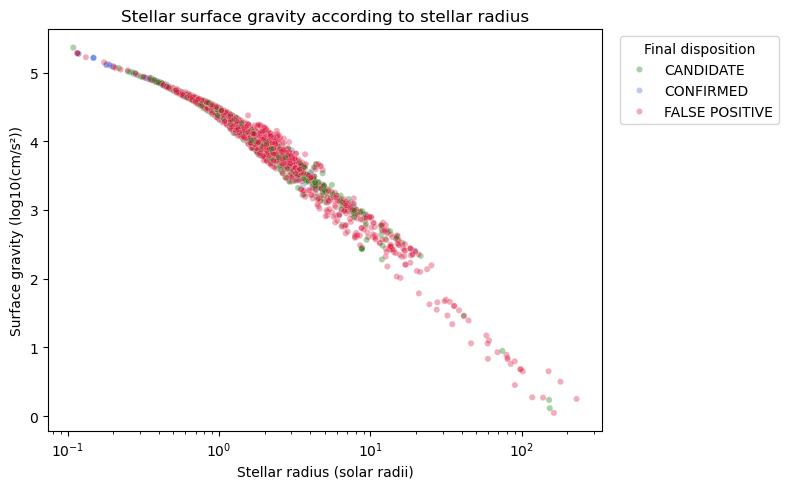

In [59]:
pair = get_positive_pair(
    "koi_srad",
    "koi_slogg"
)

draw_scatter(
    pair,
    x="koi_srad",
    y="koi_slogg",
    title="Stellar surface gravity according to stellar radius",
    xlabel="Stellar radius (solar radii)",
    ylabel="Surface gravity (log10(cm/s²))",
    log_x=True,
    log_y=False
)

`koi_slogg` et `koi_srad` présentent une relation négative importante et contiennent donc une partie d’information redondante sur l’étoile hôte. Les deux variables seront conservées provisoirement, puis leur redondance pourra être évaluée lors de la sélection des variables.


##### 9.2.6 <u> `koi_srad` x `koi_model_snr` : </u>

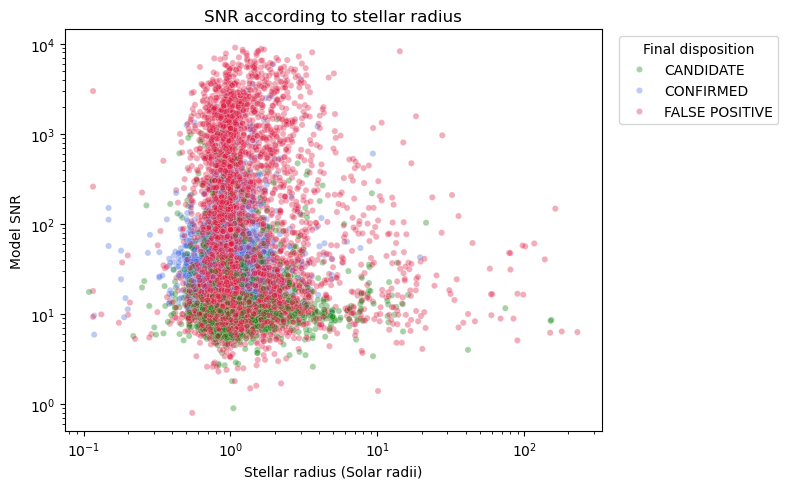

In [60]:
pair = get_positive_pair(
    "koi_srad",
    "koi_model_snr"
)

draw_scatter(
    pair,
    x="koi_srad",
    y="koi_model_snr",
    title="SNR according to stellar radius",
    xlabel="Stellar radius (Solar radii)",
    ylabel="Model SNR",
    log_x=True,
    log_y=True
)

La relation directe entre `koi_srad` et `koi_model_snr` semble faible. `koi_srad` ne sera toutefois **pas supprimée uniquement sur cette base**, car elle peut contribuer au modèle par interaction avec d’autres variables comme `koi_prad`, `koi_depth` ou `koi_teq`.


##### 9.2.7 <u> `koi_kepmag` x `koi_model_snr` : </u>

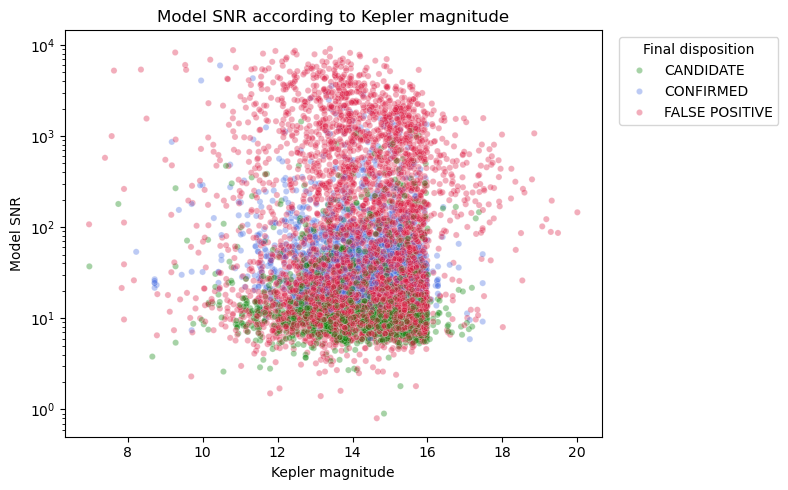

In [61]:
pair = get_positive_pair(
    "koi_kepmag",
    "koi_model_snr"
)

draw_scatter(
    pair,
    x="koi_kepmag",
    y="koi_model_snr",
    title="Model SNR according to Kepler magnitude",
    xlabel="Kepler magnitude",
    ylabel="Model SNR",
    log_x=False,
    log_y=True
)

`koi_kepmag` présente au mieux une relation faible avec `koi_model_snr`. Elle ne suffit donc pas, à elle seule, à caractériser la qualité du signal, mais elle sera conservée provisoirement comme variable liée aux conditions d’observation.


<a id="glossaire"></a>
### 10. <u>Astronomy glossary</u>

| Terme | Définition |
|---------------------------------|---|
| **Exoplanète** | Planète située en dehors du Système solaire. |
| **KOI — Kepler Object of Interest** | Objet ou signal détecté par la mission Kepler pouvant correspondre à une exoplanète candidate. Un KOI peut ensuite être classé comme exoplanète confirmée, candidat ou faux positif. |
| **KIC — Kepler Input Catalog** | Catalogue d’entrée utilisé par la mission Kepler pour identifier et caractériser les étoiles observées. Certaines variables du dataset, comme les coordonnées et certains paramètres stellaires, proviennent de ce catalogue. |
| **Méthode des transits** | Technique de détection indirecte d’exoplanètes fondée sur l’observation photométrique de la baisse de luminosité d’une étoile lorsqu’une planète passe devant elle. |
| **Durée du transit** | Intervalle de temps pendant lequel un candidat exoplanétaire passe devant son étoile hôte du point de vue de l’observateur. Ce passage provoque une diminution temporaire de la luminosité mesurée de l’étoile. |
| **Période orbitale** | Aussi appelée **période de révolution**, durée nécessaire à un astre pour accomplir une révolution complète autour d’un autre astre, par exemple une planète autour du Soleil. |
| **Profondeur du transit** | Baisse temporaire de la luminosité observée d’une étoile lorsqu’un candidat exoplanétaire passe devant elle. |
| **Rayon planétaire ($R_p$)** | Taille physique estimée d’une exoplanète. Dans ce dataset, elle est calculée à partir du rapport des rayons planète-étoile et du rayon stellaire. |
| **Température d’équilibre** | Estimation théorique de la température d’une planète, calculée à partir de l’énergie reçue de son étoile et de la chaleur qu’elle réémet. |
| **Flux d’insolation** | Énergie reçue par une planète depuis son étoile. Dans ce dataset, cette valeur est donnée par comparaison avec l’énergie reçue par la Terre depuis le Soleil. |
| **Rapport signal/bruit — SNR** | Indicateur comparant l’intensité d’un signal au niveau de bruit ou d’incertitude dans les mesures. Dans le contexte du transit, un SNR élevé signifie que la baisse de luminosité est plus clairement détectable. |
| **Paramètre d’impact du transit ($\beta$)** | Distance projetée séparant le centre de l’étoile et le centre de la planète lors du transit, exprimée en fraction du rayon de l’étoile. |
| **Température stellaire effective** | Température théorique associée au rayonnement global d’une étoile. Elle permet de caractériser sa température et influence l’énergie reçue par un candidat exoplanétaire. |
| **Gravité de surface stellaire** | Accélération due à la gravité à la surface d’une étoile. Elle dépend notamment de sa masse et de son rayon. Dans le dataset, elle est exprimée sous forme logarithmique avec `koi_slogg`. |
| **Rayon stellaire ($R_*$)** | Taille estimée d’une étoile, souvent exprimée par comparaison avec le rayon du Soleil. Le rayon de l’étoile hôte peut influencer l’interprétation du transit observé. |
| **Ascension droite ($\alpha$)** | Coordonnée équatoriale analogue à la longitude terrestre, mesurant la position est-ouest d’un objet sur la sphère céleste à partir du point vernal. Elle peut être exprimée en heures ou en degrés ; dans ce dataset, `ra` est exprimée en degrés. |
| **Déclinaison ($\delta$)** | Coordonnée équatoriale analogue à la latitude terrestre, mesurant la position nord-sud d’un objet par rapport à l’équateur céleste. Elle est exprimée en degrés et varie théoriquement de −90° à +90°. |
| **Magnitude apparente** | Mesure de la luminosité d’un objet telle qu’elle est observée depuis la Terre. L’échelle est inversée : plus la magnitude est faible, plus l’objet apparaît lumineux. |
| **Magnitude de Kepler ($K_p$)** | Magnitude apparente mesurée dans la bande d’observation du télescope Kepler, qui couvre une large partie du spectre visible. Une valeur plus faible de $K_p$ correspond à un objet plus lumineux, ce qui peut améliorer la précision photométrique du signal observé. |
| **Robovetter** | Algorithme de la NASA fondé sur des règles logiques, et non sur l’apprentissage automatique, utilisé pour classer les signaux du catalogue final des exoplanètes de Kepler (DR25) en distinguant les signaux planétaires des faux positifs. |
| **Étoiles binaires à éclipses** | Système stellaire composé de deux étoiles en orbite l’une autour de l’autre, alignées de telle sorte qu’elles se masquent mutuellement périodiquement depuis la Terre. |
| **Contamination lumineuse (*Flux contamination*)** | Phénomène au cours duquel le signal lumineux mesuré pour une étoile cible est pollué par la lumière d’étoiles voisines situées dans le même pixel ou la même ouverture photométrique. |
| **Coïncidence de période (*Ephemeris Match*)** | Situation dans laquelle un signal détecté sur une étoile cible possède une période orbitale et une époque de transit identiques à celles d’un autre objet connu dans le même champ de vue, généralement une binaire à éclipses brillante. |


<a id="sources"></a>

### 11. <u>Sources</u>

Les définitions des colonnes, le contexte de la mission et les informations sur les objets d'intérêt de Kepler ont été vérifiés à partir des sources suivantes :

- [NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/) : catalogue et données relatives aux exoplanètes ;
- [NASA Exoplanet Archive — Kepler Objects of Interest columns](https://exoplanetarchive.ipac.caltech.edu/docs/API_kepcandidate_columns.html) : définition des variables KOI utilisées dans ce notebook ;
- [NASA — Kepler mission](https://science.nasa.gov/mission/kepler/) : contexte général de la mission spatiale Kepler et de sa recherche d'exoplanètes.
